# Анализ данных и подготовка признаков — Предсказание выкупа заказов

**Задача:** по данным AmoCRM предсказать, выкупит ли клиент заказ наложенным платежом (binary classification: `buyout_flag`).

**Контекст:** интернет-магазин товаров для здоровья отправляет заказы через Почту России и СДЭК наложенным платежом. Часть клиентов не забирает товар — это приводит к расходам на доставку и возврат. Данные: выгрузка из AmoCRM за период март 2025 — март 2026, одна строка = одна сделка.

**Ключевой инсайт:** повторные клиенты (`contact_Число сделок >= 1`) выкупают в 97%+ случаев — для них достаточно модели на одном признаке. Основная сложность — **новые клиенты** (buyout ~32.5%), для которых строится LogReg на ~27 признаках.

Этот ноутбук:
1. Загружает и очищает данные
2. Показывает общий обзор и обосновывает фокус на новых клиентах
3. Переключается на новых клиентов и строит EDA по признакам для обучения
4. Создаёт новые признаки (через YAML-driven pipeline)
5. Разделяет данные на train/test/val (60/20/20) и сохраняет для ноутбука обучения

In [1]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import warnings
import calendar
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from utils import load_feature_config, build_features

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)


In [2]:
# === Вспомогательные функции визуализации ===
GREEN = '#2ecc71'
RED = '#e74c3c'
LIGHT_GRAY = '#ecf0f1'

LEAD_QUAL_ORDER = ['А - лид', 'В - лид', 'С - лид', 'D/Неквал лид', 'D - лид', 'Е - лид', 'Неквал лид']

CUSTOM_ORDERS = {
    '_deal_group': ['0 (новый)', '1', '2', '3', '4', '5+'],
    'price_bin': ['0-5k', '5-8k', '8-15k', '15k+', 'unknown'],
    'cart_bin': ['1-8', '9-12', '13+'],
    'manager_bin': ['0-800', '800-1.8k', '1.8-3k', '3k+'],
    'delta_bin': ['<30мин', '30-60мин', '1-2ч', '>2ч'],
}

def _ordered_categories(col, counts_index, n_tot):
    """Порядок меток: спецпорядок для известных столбцов, иначе по количеству."""
    idx_set = set(counts_index)
    def by_total_desc(keys):
        return sorted(keys, key=lambda x: -int(n_tot.loc[x]))

    if col in CUSTOM_ORDERS:
        return [c for c in CUSTOM_ORDERS[col] if c in idx_set]

    if col == 'sale_weekday':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'lead_Квалификация лида':
        order = [q for q in LEAD_QUAL_ORDER if q in idx_set]
        rest = [x for x in idx_set if x not in order]
        return order + by_total_desc(rest)

    return by_total_desc(list(idx_set))


def plot_feature_two_panel(df, col, title, top_n=None):
    """Категориальный признак: верх - count bars, низ - stacked 100% bars."""
    work = df
    if top_n is not None:
        keep = df[col].value_counts().head(top_n).index
        work = df.loc[df[col].isin(keep)]
    g = work.groupby(col, observed=True)['buyout_flag']
    n_buy = g.sum()
    n_tot = g.count()
    n_cancel = n_tot - n_buy
    rate = (n_buy / n_tot.replace(0, np.nan)).fillna(0.0)

    order = _ordered_categories(col, n_buy.index, n_tot)
    n_buy = n_buy.reindex(order, fill_value=0)
    n_cancel = n_cancel.reindex(order, fill_value=0)
    rate = rate.reindex(order, fill_value=0)

    labels = [str(x) for x in order]
    x = np.arange(len(labels))
    w = 0.36

    _fw, _fh = (14, 9) if top_n is not None else (11, 8)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(_fw, _fh), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.bar(x - w/2, n_buy.values, width=w, color=GREEN, label='Выкуп (продажи)')
    ax1.bar(x + w/2, n_cancel.values, width=w, color=RED, label='Отмена (без выкупа)')
    ax1.set_ylabel('Количество')
    ax1.legend(loc='center right')
    ax1.grid(axis='y', alpha=0.3, zorder=0)

    # Нижний график: stacked bars. Пустые бины (n_tot=0) оставляем серыми.
    n_tot_vals = (n_buy + n_cancel).values
    for i_bar in range(len(x)):
        if n_tot_vals[i_bar] == 0:
            ax2.bar(x[i_bar], 1.0, color=LIGHT_GRAY, edgecolor='#bdc3c7', linewidth=0.5)
        else:
            ax2.bar(x[i_bar], rate.values[i_bar], color=GREEN)
            ax2.bar(x[i_bar], 1.0 - rate.values[i_bar], bottom=rate.values[i_bar], color=RED)

    ax2.set_ylabel('Доля')
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=GREEN, label='Доля выкупа'),
                      Patch(color=RED, label='Доля отмен')]
    if 0 in n_tot_vals:
        legend_handles.append(Patch(color=LIGHT_GRAY, label='Нет данных'))
    ax2.legend(handles=legend_handles, loc='center right')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3, zorder=0)

    tbl = pd.DataFrame({
        'выкуп': n_buy.astype(int).values,
        'без_выкупа': n_cancel.astype(int).values,
        'всего': (n_buy + n_cancel).astype(int).values,
        'buyout_rate': rate.values,
    }, index=labels)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string(float_format='%.3f'))

    plt.tight_layout(); plt.show()


def plot_numeric_buyout_by_hist(df, col, title=None, bins=30, xlim=None):
    """Числовой признак: верх - наложенные гистограммы, низ - доля выкупа по бинам."""
    if title is None:
        title = col
    s = pd.to_numeric(df[col], errors='coerce')
    mask = s.notna()
    if not mask.any():
        print(f'\n{col}: нет данных (всё NaN), пропуск\n')
        return
    vals = s[mask].to_numpy(dtype=float)
    buy = df.loc[mask, 'buyout_flag'].astype(bool).to_numpy()

    hist_range = None
    lo_r = hi_r = None
    if xlim is not None:
        lo_r, hi_r = xlim[0], xlim[1]
        if lo_r is None: lo_r = float(np.min(vals))
        if hi_r is None: hi_r = float(np.max(vals))
        win = (vals >= lo_r) & (vals <= hi_r)
        vals_f, buy_f = vals[win], buy[win]
        if vals_f.size == 0:
            print(f'\n{col}: нет точек в xlim, пропуск\n')
            return
        hist_range = (lo_r, hi_r)
    else:
        vals_f, buy_f = vals, buy

    _, edges = np.histogram(vals_f, bins=bins, range=hist_range) if hist_range else np.histogram(vals_f, bins=bins)
    nbins = len(edges) - 1
    idx = np.clip(np.searchsorted(edges, vals_f, side='right') - 1, 0, nbins - 1)

    n_tot = np.bincount(idx, minlength=nbins)[:nbins].astype(int)
    n_buy_arr = np.bincount(idx[buy_f], minlength=nbins)[:nbins].astype(int)
    n_cancel_arr = n_tot - n_buy_arr
    rate = np.divide(n_buy_arr.astype(float), n_tot, out=np.full(nbins, np.nan), where=n_tot > 0)

    left = edges[:-1]
    widths = np.diff(edges)
    mean_v = float(np.mean(vals_f))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1.25]})
    fig.suptitle(f'{title} (bins={nbins})', fontsize=13)

    ax1.hist(vals_f[buy_f], bins=edges, color=GREEN, alpha=0.55,
             label='Выкуп (продажи)', edgecolor='none')
    ax1.hist(vals_f[~buy_f], bins=edges, color=RED, alpha=0.55,
             label='Отмена (без выкупа)', edgecolor='none')
    ax1.axvline(mean_v, color='black', linestyle='--', linewidth=1, label='Среднее', zorder=5)
    ax1.set_ylabel('Количество')
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    # Нижний график: доля выкупа. Пустые бины оставляем белыми.
    for i_bar in range(nbins):
        if n_tot[i_bar] == 0:
            continue  # пустой бин - не рисуем ничего
        ax2.bar(left[i_bar], rate[i_bar], width=widths[i_bar], align='edge',
                color=GREEN, edgecolor='none', linewidth=0)
        ax2.bar(left[i_bar], 1.0 - rate[i_bar], width=widths[i_bar],
                bottom=rate[i_bar], align='edge', color=RED, edgecolor='none', linewidth=0)

    ax2.set_ylabel('Доля')
    ax2.set_xlabel(col)
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color=GREEN, label='Доля выкупа'),
                        Patch(color=RED, label='Доля отмен')], loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(mean_v, color='black', linestyle='--', linewidth=1, zorder=5)

    if hist_range is not None:
        ax2.set_xlim(lo_r, hi_r)

    bin_lbl = [f'[{left[i]:.4g}, {edges[i+1]:.4g}]' for i in range(nbins)]
    tbl = pd.DataFrame({'выкуп': n_buy_arr, 'без_выкупа': n_cancel_arr, 'всего': n_tot}, index=bin_lbl)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string())

    plt.tight_layout(); plt.show()

print('Функции визуализации определены')

Функции визуализации определены


## 1. Загрузка и очистка данных

Датасет содержит записи о заказах из AmoCRM за период март 2025 — март 2026. Каждая строка — одна сделка (lead) с информацией о клиенте, товаре, доставке и статусе.

Очистка:
- Убираем строки с `outcome_unknown == True` — сделки, по которым исход ещё неизвестен
- Приводим `buyout_flag` к бинарному формату (0/1)
- Конвертируем типы столбцов (даты, числа)

In [3]:
DATA_PATH = 'dataset_2025-03-01_2026-03-29_external.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Загружено строк: {len(df_raw)}")

# Убираем строки с неизвестным исходом
df = df_raw[df_raw['outcome_unknown'] == False].copy()
print(f"С известным исходом: {len(df)}")

# Целевая переменная
df['buyout_flag'] = df['buyout_flag'].map(
    {'True': 1, 'true': 1, True: 1, 'False': 0, 'false': 0, False: 0}
).astype(int)

# Приведение типов
df['sale_ts'] = pd.to_numeric(df['sale_ts'], errors='coerce')
df['lead_created_at'] = pd.to_numeric(df['lead_created_at'], errors='coerce')
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['lead_price'] = pd.to_numeric(df['lead_price'], errors='coerce')
df['contact_Число сделок'] = pd.to_numeric(df.get('contact_Число сделок'), errors='coerce')

for col in ['lead_Вес (грамм)*', 'lead_Длина', 'lead_Ширина', 'lead_Высота',
             'lead_Скидка', 'lead_Стоимость доставки', 'lead_Масса (гр)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

buyout_rate = df['buyout_flag'].mean()
print(f"\nBuyout rate: {buyout_rate:.4f} ({buyout_rate*100:.1f}%)")
print(f"Выкуп: {df['buyout_flag'].sum()}, Отказ: {(1 - df['buyout_flag']).sum():.0f}")

Загружено строк: 18887
С известным исходом: 17966

Buyout rate: 0.8283 (82.8%)
Выкуп: 14882, Отказ: 3084


## 2. Общий обзор данных

Прежде чем строить модель, посмотрим на общую картину: распределение целевой переменной и buyout rate для двух ключевых групп клиентов — новых и повторных.

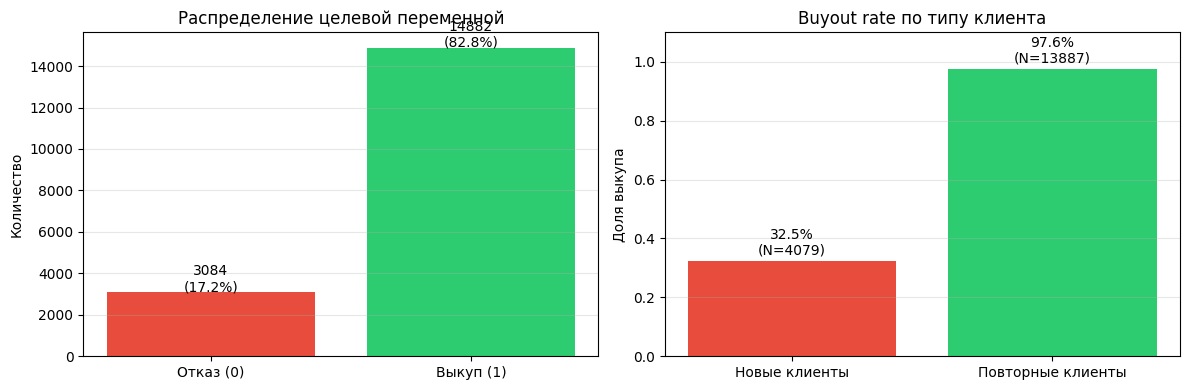

Всего строк: 17966
Новые клиенты: 4079 (22.7%), buyout: 0.3248
Повторные:     13887 (77.3%), buyout: 0.9762


In [4]:
# Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['buyout_flag'].value_counts().sort_index()
axes[0].bar(['Отказ (0)', 'Выкуп (1)'], counts.values, color=[RED, GREEN])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].grid(axis='y', alpha=0.3)

# Новые vs повторные
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
groups = pd.DataFrame({
    'type': ['Новые клиенты', 'Повторные клиенты'],
    'count': [is_new.sum(), (~is_new).sum()],
    'buyout_rate': [df.loc[is_new, 'buyout_flag'].mean(), df.loc[~is_new, 'buyout_flag'].mean()]
})

bars = axes[1].bar(groups['type'], groups['buyout_rate'], color=[RED, GREEN])
axes[1].set_title('Buyout rate по типу клиента')
axes[1].set_ylabel('Доля выкупа')
axes[1].set_ylim(0, 1.1)
for bar, rate, cnt in zip(bars, groups['buyout_rate'], groups['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                 f'{rate:.1%}\n(N={cnt})', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Всего строк: {len(df)}")
print(f"Новые клиенты: {is_new.sum()} ({is_new.mean()*100:.1f}%), buyout: {df.loc[is_new, 'buyout_flag'].mean():.4f}")
print(f"Повторные:     {(~is_new).sum()} ({(~is_new).mean()*100:.1f}%), buyout: {df.loc[~is_new, 'buyout_flag'].mean():.4f}")

### Ключевой инсайт: два типа клиентов

Данные показывают радикальное различие между двумя группами:
- **Повторные клиенты** (77% заказов) — buyout 97%+. Клиент, заказывавший ранее, почти гарантированно выкупит снова. Предсказание тривиально: одного признака `contact_Число сделок` достаточно.
- **Новые клиенты** (23% заказов) — buyout ~32.5%. Именно здесь бизнес теряет деньги на доставке невыкупленных заказов, и именно здесь ML-модель принесёт наибольшую пользу.

Чтобы убедиться в этом визуально, построим buyout rate в разбивке по количеству прошлых заказов клиента:


Buyout rate по числу прошлых заказов клиента
             выкуп  без_выкупа  всего  buyout_rate
_deal_group                                       
0 (новый)     1325        2754   4079        0.325
1             9963         233  10196        0.977
2             1855          63   1918        0.967
3              627          18    645        0.972
4              368           4    372        0.989
5+             744          12    756        0.984


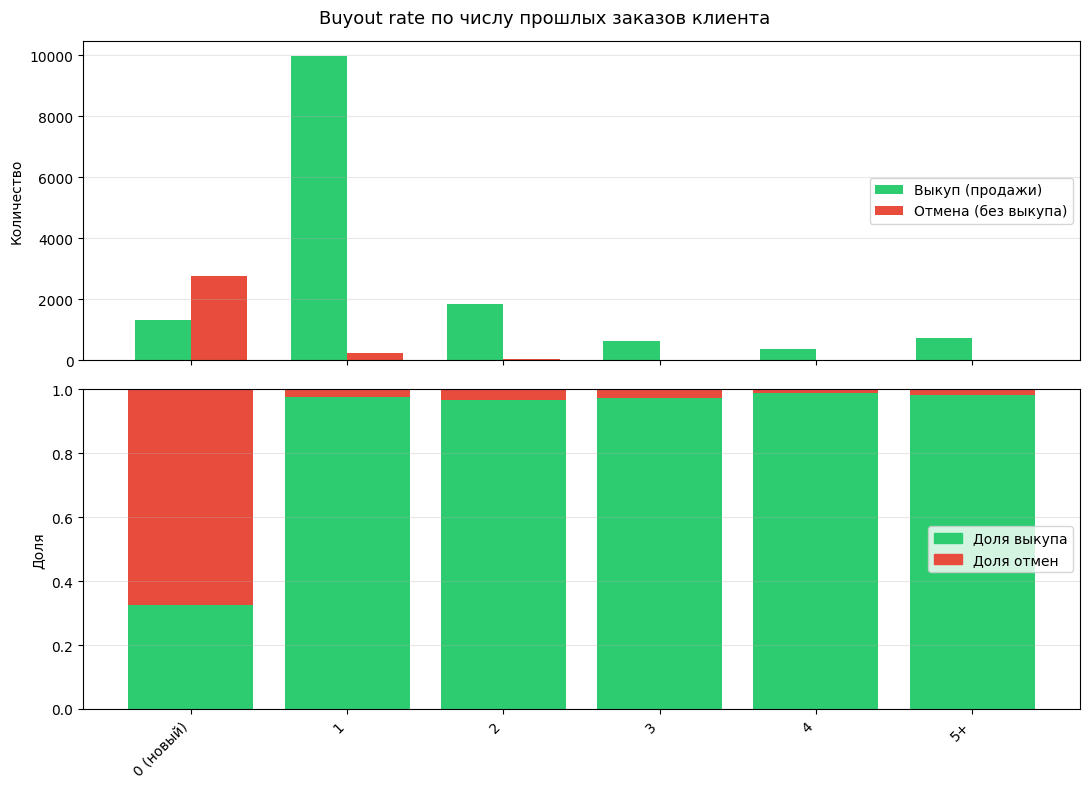

In [5]:
# Группируем по числу прошлых сделок
deal_counts = df['contact_Число сделок'].fillna(0).astype(int)
deal_counts = deal_counts.clip(upper=5)
df['_deal_group'] = deal_counts.astype(str)
df.loc[df['_deal_group'] == '5', '_deal_group'] = '5+'
df.loc[df['_deal_group'] == '0', '_deal_group'] = '0 (новый)'

plot_feature_two_panel(df, '_deal_group', 'Buyout rate по числу прошлых заказов клиента')

df.drop(columns=['_deal_group'], inplace=True)

## 3. Фокус на новых клиентах

График выше наглядно демонстрирует: начиная с 1-го прошлого заказа buyout rate >96%. Анализировать и моделировать повторных клиентов нет смысла — для них достаточно простой модели на одном признаке.

**С этого момента весь дальнейший анализ проводится только на новых клиентах** — записях, где `contact_Число сделок` = NaN или 0. Именно для этого сегмента строится основная ML-модель.

In [6]:
# Сохраняем полный датасет для финального разделения
df_full = df.copy()

# Переключаемся на новых клиентов
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
df = df[is_new].copy()

print(f'Новые клиенты: {len(df)}')
print(f'Buyout rate: {df["buyout_flag"].mean():.4f} ({df["buyout_flag"].mean()*100:.1f}%)')
print(f'Выкуп: {df["buyout_flag"].sum()}, Отказ: {(1 - df["buyout_flag"]).sum():.0f}')

Новые клиенты: 4079
Buyout rate: 0.3248 (32.5%)
Выкуп: 1325, Отказ: 2754


In [7]:
# === YAML-driven feature pipeline ===
# 1. Конфиг признаков (см. features.yaml)
config = load_feature_config('features.yaml')

# 2. Гео-словарь (база городов России + Крым)
with open('russia-cities.json', encoding='utf-8') as f:
    _russia_cities_raw = json.load(f)
russia_cities = [{'name': c['name'], 'region': c['region']['fullname']}
                 for c in _russia_cities_raw if c.get('name')]
russia_cities.extend([
    {'name': 'Ялта',            'region': 'Республика Крым'},
    {'name': 'Керчь',           'region': 'Республика Крым'},
    {'name': 'Севастополь',     'region': 'Севастополь'},
    {'name': 'Феодосия',        'region': 'Республика Крым'},
    {'name': 'Красноперекопск', 'region': 'Республика Крым'},
    {'name': 'Евпатория',       'region': 'Республика Крым'},
    {'name': 'Алушта',          'region': 'Республика Крым'},
])

# 3. Карта manager_id -> число сделок (агрегат по полному датасету)
manager_map = df_full.groupby('lead_responsible_user_id').size().to_dict()

# 4. Группы менеджеров по buyout rate новых клиентов.
#    Менеджеры с rate >= 40% → mgr_high, 20-40% → mgr_mid, <20% → mgr_low.
#    Различие в buyout rate между группами — до 30 п.п.
mgr_rates = df.groupby('lead_responsible_user_id')['buyout_flag'].mean()
mgr_group_map = {}
for mgr_id, rate in mgr_rates.items():
    mgr_group_map[mgr_id] = (
        'mgr_high' if rate >= 0.4 else
        'mgr_mid'  if rate >= 0.2 else
        'mgr_low'
    )

# 5. Карта крупных городов (население >= 500 тыс.)
big_city_map = {c['name']: 1 for c in _russia_cities_raw
                if c.get('population', 0) >= 500_000}

# 6. Препроцессинг — сразу для df новых клиентов (для EDA ниже)
context = {
    'manager_map': manager_map,
    'russia_cities': russia_cities,
    'mgr_group_map': mgr_group_map,
    'big_city_map': big_city_map,
}
df, feat_cols = build_features(df, config, context)

print(f'Признаки готовы: cat={len(feat_cols.cat_cols)}, num={len(feat_cols.num_cols)}, '
      f'bin={len(feat_cols.bin_cols)}, geo={len(feat_cols.geo_cols)}, te={len(feat_cols.te_cat_cols)}')
print(f'Гео-база: {len(russia_cities)} городов')
n_unknown = (df['city_clean'] == '__unknown__').sum()
print(f'Unknown городов: {n_unknown} ({n_unknown/len(df)*100:.1f}%)')
print(f'Крупных городов (>=500k): {len(big_city_map)}')
print(f'Групп менеджеров: { {v: sum(1 for x in mgr_group_map.values() if x == v) for v in sorted(set(mgr_group_map.values()))} }')

Признаки готовы: cat=15, num=0, bin=3, geo=2, te=0
Гео-база: 1109 городов
Unknown городов: 510 (12.5%)
Крупных городов (>=500k): 36
Групп менеджеров: {'mgr_high': 3, 'mgr_low': 18, 'mgr_mid': 6}


## 4. EDA — Категориальные признаки (новые клиенты)

Для каждого категориального признака, который будет использоваться в модели, строим двухпанельный график:
- **Верх:** количество выкупов и отказов по категориям (side-by-side bars)
- **Низ:** доля выкупа в каждой категории (stacked 100% bars)

Важно: для ряда признаков **NaN — это информативный класс**, а не пропуск. NaN в `lead_Квалификация лида`, `lead_Категория и варианты выбора`, `lead_Модель телефона` и `lead_будущие покупки` означает, что менеджер не звонил клиенту.

`lead_responsible_user_id` — идентификатор менеджера. В модели кодируется one-hot (26 уникальных менеджеров). L1-регуляризация обнуляет малозначимых менеджеров автоматически.


lead_Служба доставки
                      выкуп  без_выкупа  всего  buyout_rate
lead_Служба доставки                                       
СДЭК                    270        2090   2360        0.114
Почта                  1047         652   1699        0.616
Прочее                    8          12     20        0.400


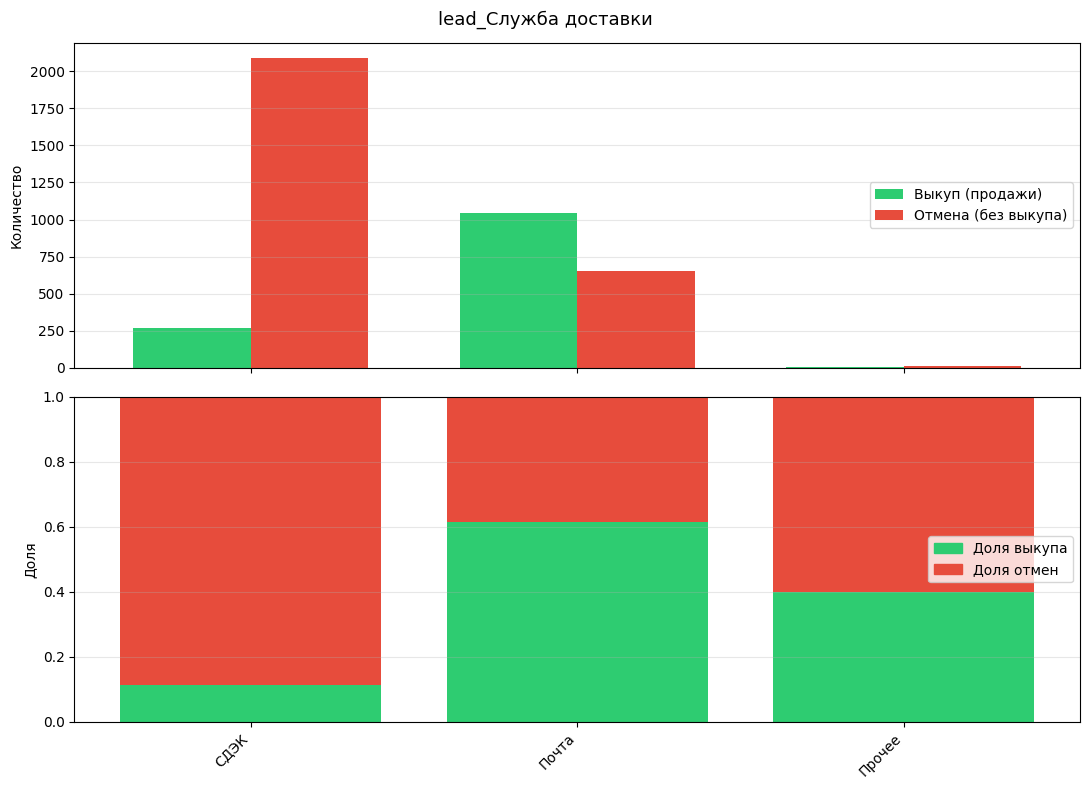


lead_Тариф Доставки
                     выкуп  без_выкупа  всего  buyout_rate
lead_Тариф Доставки                                       
Склад                  585        2228   2813        0.208
Почта                  721         480   1201        0.600
Прочее                  19          46     65        0.292


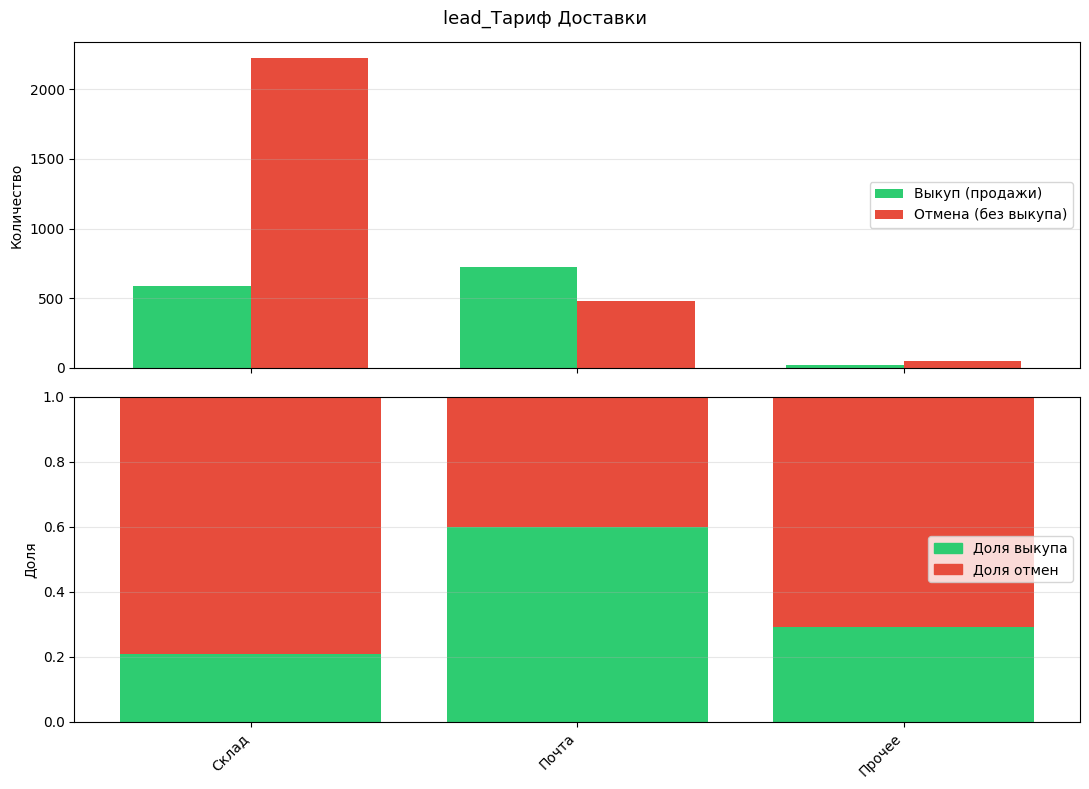


lead_Квалификация лида
                        выкуп  без_выкупа  всего  buyout_rate
lead_Квалификация лида                                       
А - лид                   267         887   1154        0.231
В - лид                   142         647    789        0.180
С - лид                    95         411    506        0.188
D/Неквал лид               16          34     50        0.320


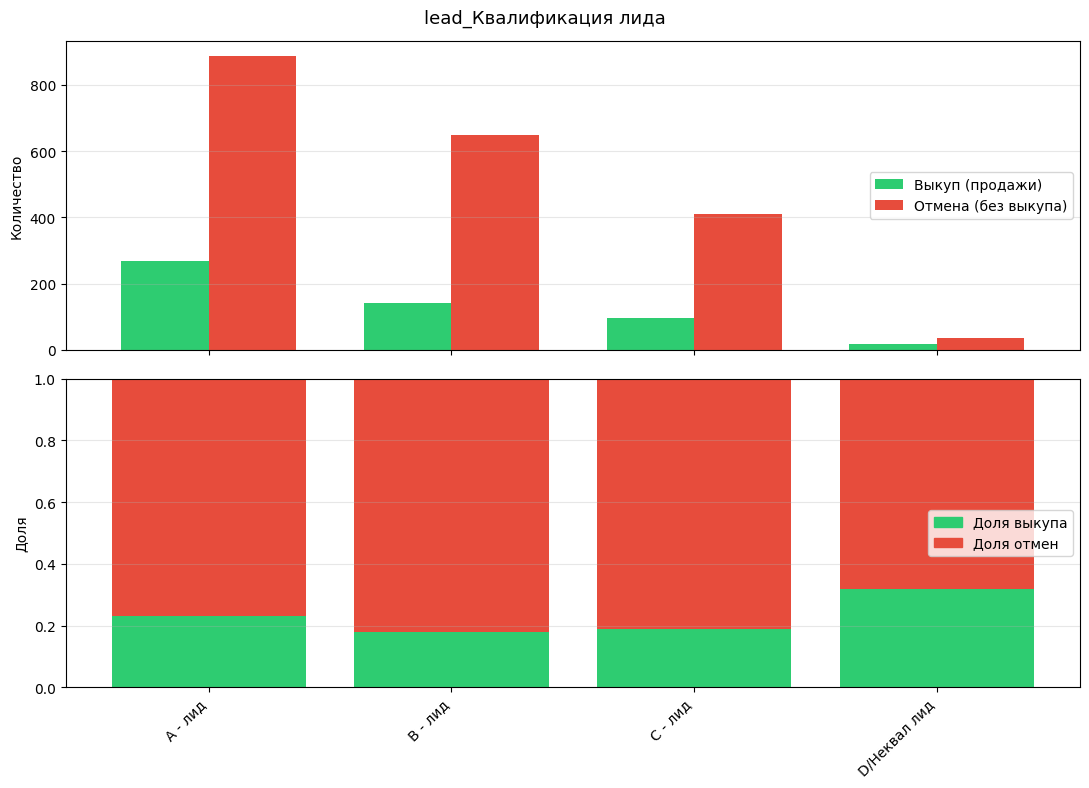


lead_Категория и варианты выбора
                                  выкуп  без_выкупа  всего  buyout_rate
lead_Категория и варианты выбора                                       
S                                   111         850    961        0.116
I                                    48         431    479        0.100
D                                    40         198    238        0.168
C                                    11          62     73        0.151
Нет категории                        15          25     40        0.375


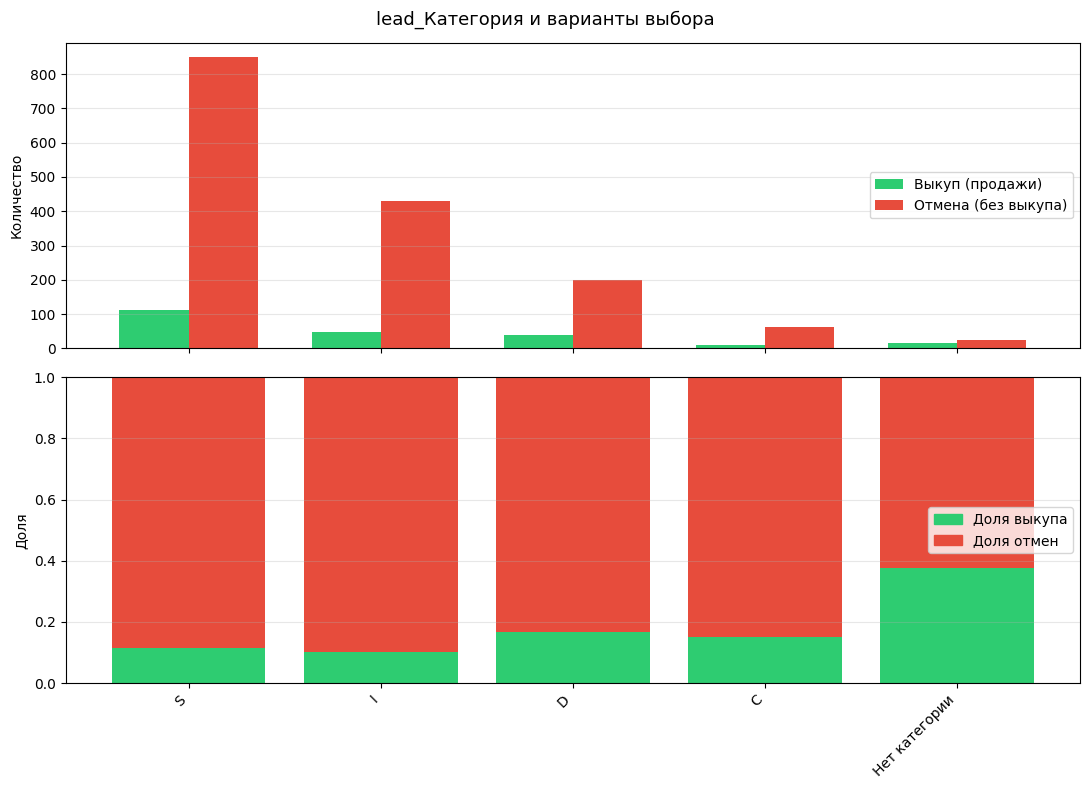


lead_Модель телефона
                      выкуп  без_выкупа  всего  buyout_rate
lead_Модель телефона                                       
Смартфон                415        1198   1613        0.257
Не удалось узнать       264         923   1187        0.222
Кнопочный                29          56     85        0.341


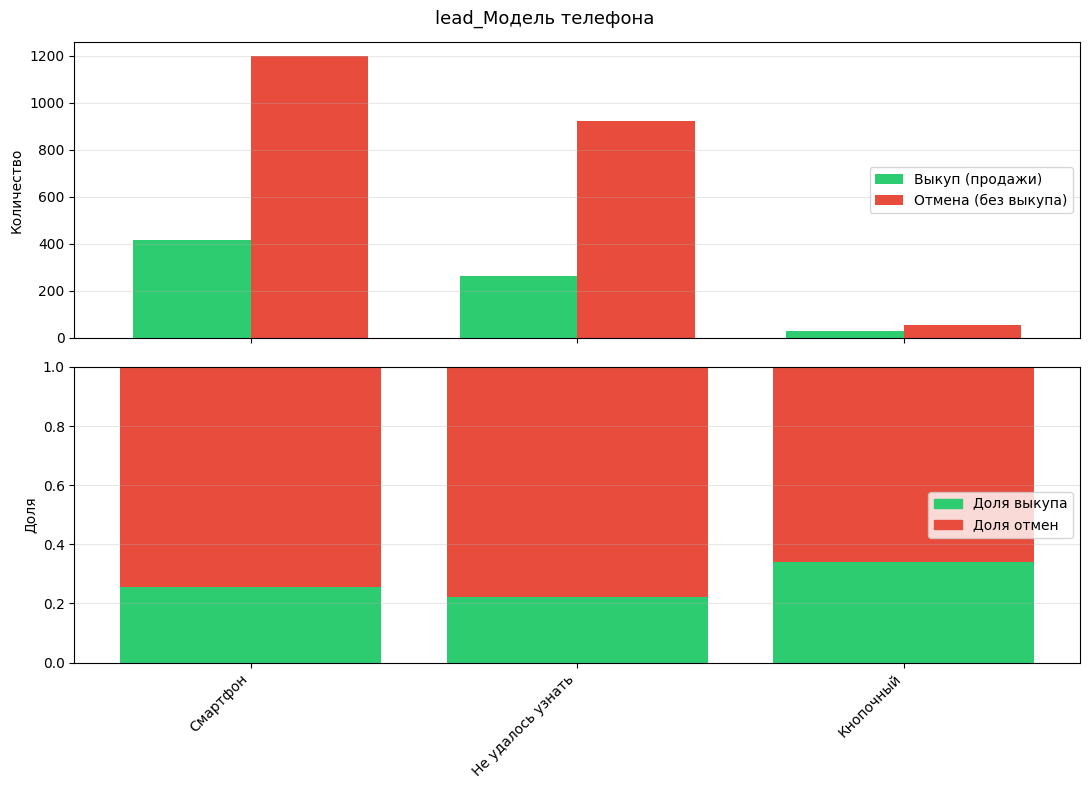


lead_Вид оплаты


                   выкуп  без_выкупа  всего  buyout_rate
lead_Вид оплаты                                         
Наложенный платеж   1287        2728   4015        0.321
Оплата онлайн         23          11     34        0.676
Оплата на карту       13           4     17        0.765
Прочее                 2          11     13        0.154


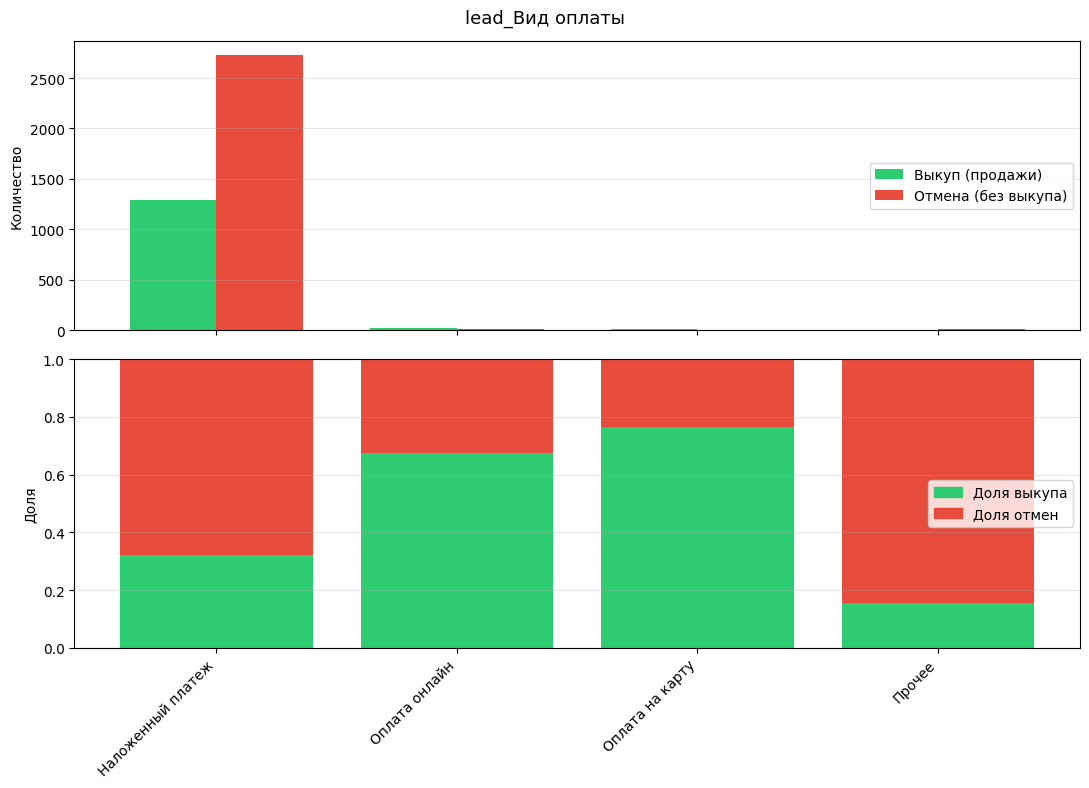


lead_group_id
               выкуп  без_выкупа  всего  buyout_rate
lead_group_id                                       
700242           340        1003   1343        0.253
546538           310         842   1152        0.269
700246           131         289    420        0.312
708650            56          72    128        0.438


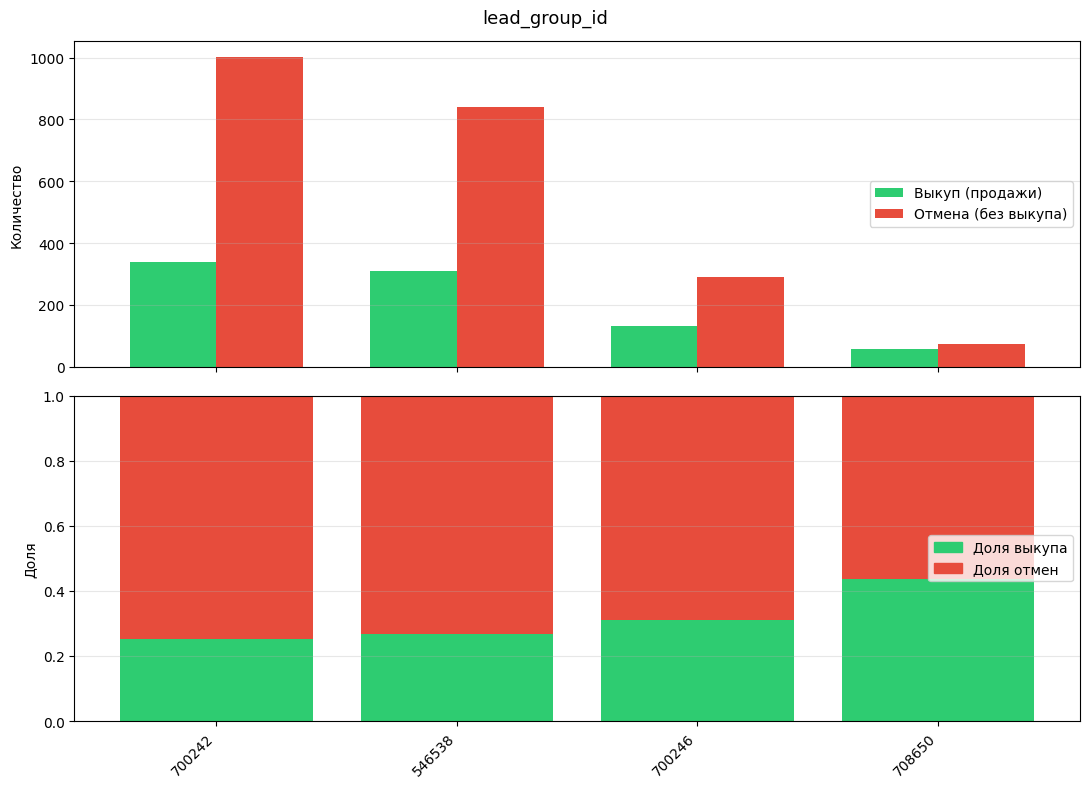


lead_Проблема


               выкуп  без_выкупа  всего  buyout_rate
lead_Проблема                                       
first           1052        2227   3279        0.321
second           234         293    527        0.444
third             39         234    273        0.143


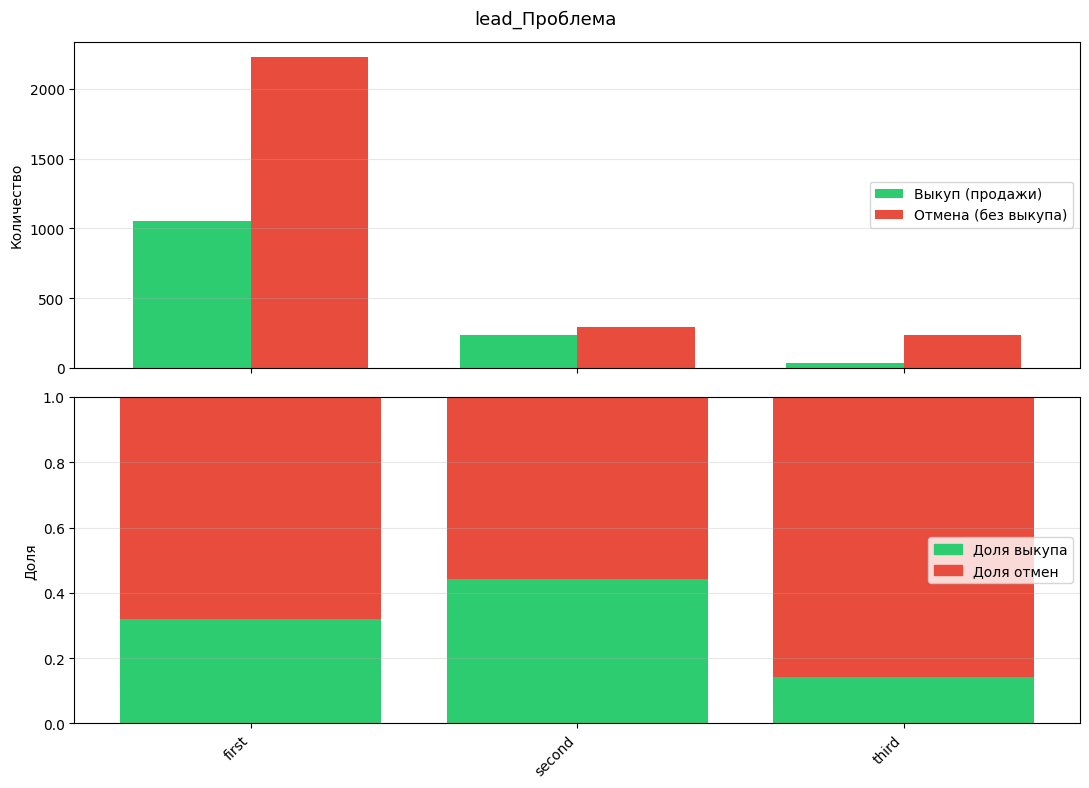


lead_responsible_user_id
                          выкуп  без_выкупа  всего  buyout_rate
lead_responsible_user_id                                       
MGR_0002                    487         544   1031        0.472
MGR_0030                    219         467    686        0.319
MGR_0001                    195         265    460        0.424
MGR_0006                    102         340    442        0.231
MGR_0003                    131         289    420        0.312
MGR_0005                     57         135    192        0.297
MGR_0009                     20         139    159        0.126
MGR_0007                     22         111    133        0.165
MGR_0004                     56          72    128        0.438
MGR_0012                     10          66     76        0.132
MGR_0008                      7          42     49        0.143
MGR_0013                      4          44     48        0.083
MGR_0011                      3          41     44        0.068
MGR_0010      

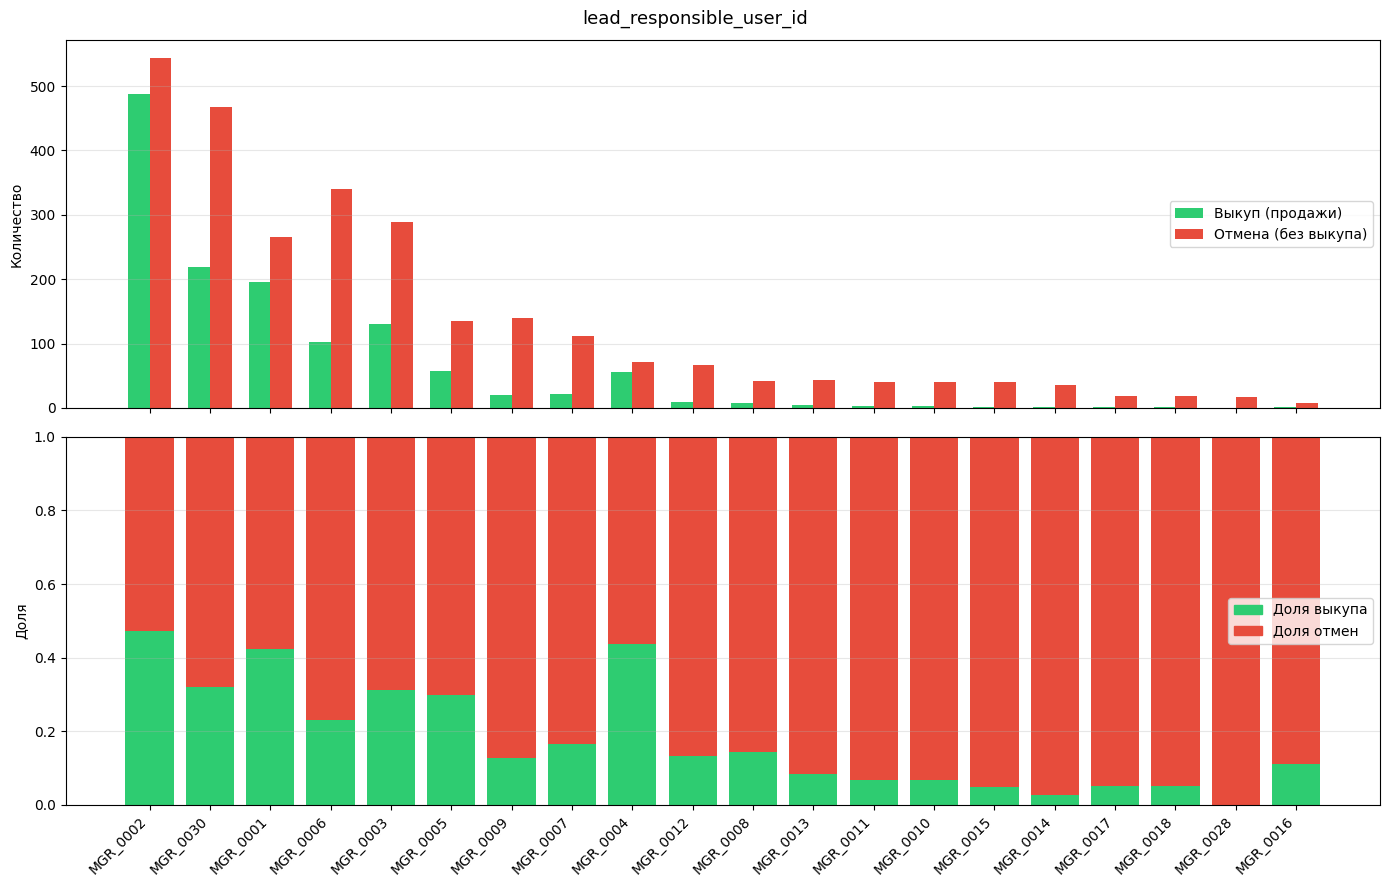

In [8]:
# Категориальные признаки для EDA (только те, что пойдут в модель)
CAT_EDA = [
    'lead_Служба доставки',                  # 3 класса: СДЭК / Почта / Прочее
    'lead_Тариф Доставки',                   # 4 класса: Почта / Склад / Прочее / остальное
    'lead_Квалификация лида',                # группировка мелких классов в 'D/Неквал лид'
    'lead_Категория и варианты выбора',      # DISC-профиль
    'lead_Модель телефона',                  #
    'lead_Вид оплаты',                       # 4 класса: 3 основных + Прочее
    'lead_group_id',                         # категориальный, класс '0' = неизвестно
    'lead_Проблема',                         # 3 группы: first / high_buyout / third
    'lead_responsible_user_id',              # 26 менеджеров, one-hot
]

for col in CAT_EDA:
    if col not in df.columns:
        print(f'{col}: отсутствует в данных, пропуск')
        continue
    n_unique = df[col].nunique()
    top_n = 20 if n_unique > 20 else None
    plot_feature_two_panel(df, col, col, top_n=top_n)

### Наблюдения по категориальным признакам (новые клиенты)

- **`lead_Служба доставки`** — самый сильный категориальный признак. Почта: buyout 61.6% (1699 заказов), СДЭК: 11.2% (2360). Разрыв между Почтой и СДЭК — более 50 п.п.
- **`lead_Тариф Доставки`** — детализирует службу доставки. Почта: 59-62%, Склад (слад-дверь + склад-склад): 10-22%, Прочее: мелкие категории. NaN отнесён к «Почта» (buyout 62.4%).
- **`lead_Квалификация лида`** — NaN (38.7%) = buyout 50.9%; A-лид: 23.1%, B-лид: 18.0%, C-лид: 18.8%. NaN (менеджер не заполнил квалификацию) = лучший предиктор выкупа.
- **`lead_Категория и варианты выбора`** — DISC-профиль клиента. NaN (56.1%) = buyout 48.1%; S: 11.6%, I: 10.0%, D: 16.8%.
- **`lead_Модель телефона`** — NaN (29.3%) = buyout 51.7%; Смартфон: 25.7%, Кнопочный: 34.1%, Не удалось узнать: 22.2%.
- **`lead_Вид оплаты`** — предоплата (онлайн/карта) = buyout 68-77%, но это лишь 1.3% заказов. 98.4% оплачивают наложенным платежом (32.1%).
- **`lead_Проблема`** — тематика заказа, сгруппирована в 3 категории: first (суставы, варикоз, ССЗ — buyout ~32%), second (бессоница, зрение, «прочее» — buyout ~44%), third (отеки, инсульт, давление — buyout ~17%).
- **`lead_group_id`** — 4 воронки. Buyout от 26% до 43%. Класс «0»/NaN → all-zeros при one-hot.
- **`lead_responsible_user_id`** — 26 менеджеров. Buyout rate варьируется от <10% до >45%. Кодируется one-hot: при 26 категориях L1-регуляризация обнуляет незначимых менеджеров, а значимые (например, MGR_0008 с высоким buyout) получают индивидуальные коэффициенты. Это существенно лучше target encoding, который «размазывает» сигнал через additive smoothing.

## 5. EDA — Числовые признаки (новые клиенты)

Для числовых признаков строим:
- **Верх:** наложенные гистограммы выкупов и отказов
- **Низ:** доля выкупа в каждом бине (stacked 100% bars)


lead_price


                        выкуп  без_выкупа  всего
lead_price                                      
[0, 1333]                  14          28     42
[1333, 2667]               26          26     52
[2667, 4000]              204         204    408
[4000, 5333]               54         114    168
[5333, 6667]              119         195    314
[6667, 8000]              319         397    716
[8000, 9333]               58         390    448
[9333, 1.067e+04]          95         192    287
[1.067e+04, 1.2e+04]       61          94    155
[1.2e+04, 1.333e+04]      107         192    299
[1.333e+04, 1.467e+04]     63         189    252
[1.467e+04, 1.6e+04]       38         127    165
[1.6e+04, 1.733e+04]       48         153    201
[1.733e+04, 1.867e+04]     21         133    154
[1.867e+04, 2e+04]         19          69     88
[2e+04, 2.133e+04]         17          49     66
[2.133e+04, 2.267e+04]      9          44     53
[2.267e+04, 2.4e+04]        8          29     37
[2.4e+04, 2.533e+04

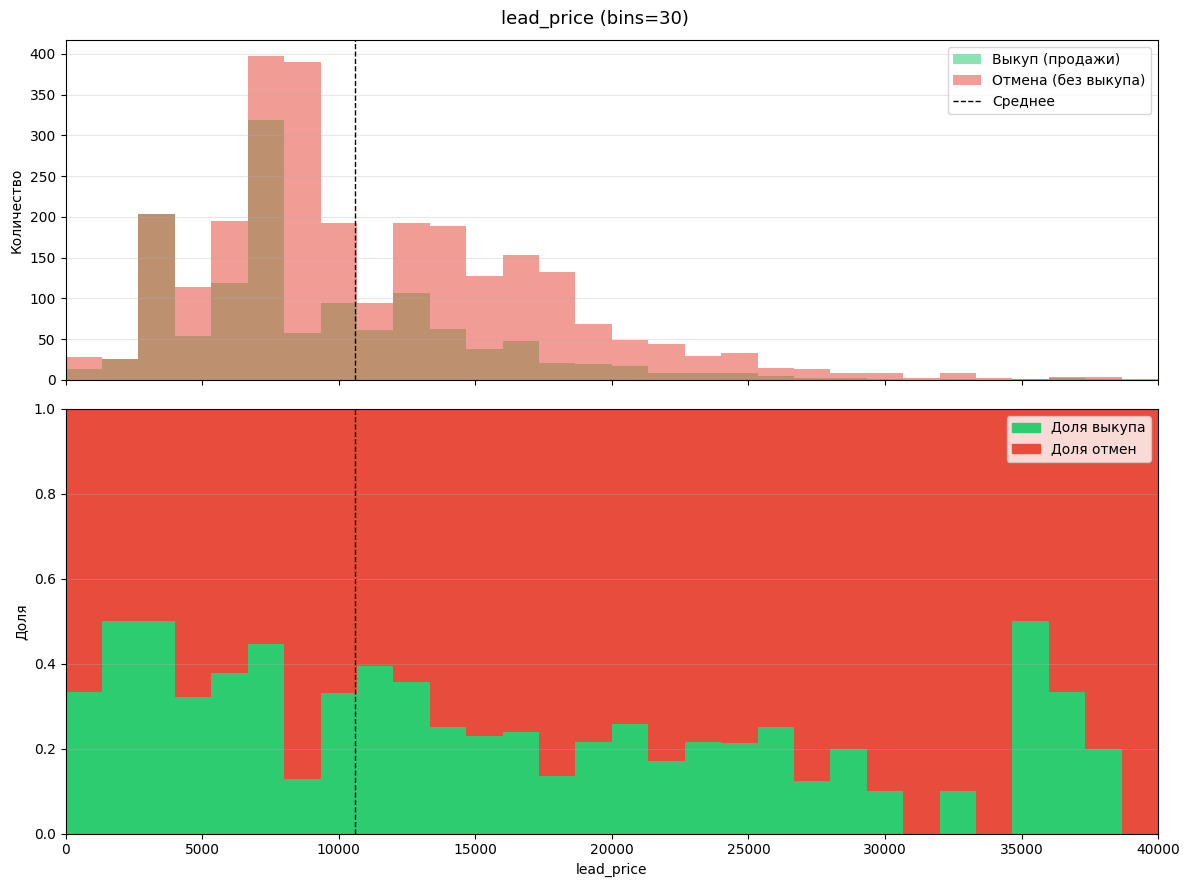


lead_Стоимость доставки
                         выкуп  без_выкупа  всего
lead_Стоимость доставки                          
[381, 431.3]                 1           2      3
[431.3, 481.6]               0           1      1
[481.6, 531.9]               1           0      1
[531.9, 582.2]               0           0      0
[582.2, 632.5]               0           1      1
[632.5, 682.8]               0           0      0
[682.8, 733.1]               2           0      2
[733.1, 783.4]               0           0      0
[783.4, 833.7]               0           0      0
[833.7, 884]                 2           0      2
[884, 934.3]                 0           0      0
[934.3, 984.6]               2           0      2
[984.6, 1035]                0           0      0
[1035, 1085]                 1           0      1
[1085, 1136]                 0           0      0
[1136, 1186]                 2           0      2
[1186, 1236]                 0           0      0
[1236, 1286]             

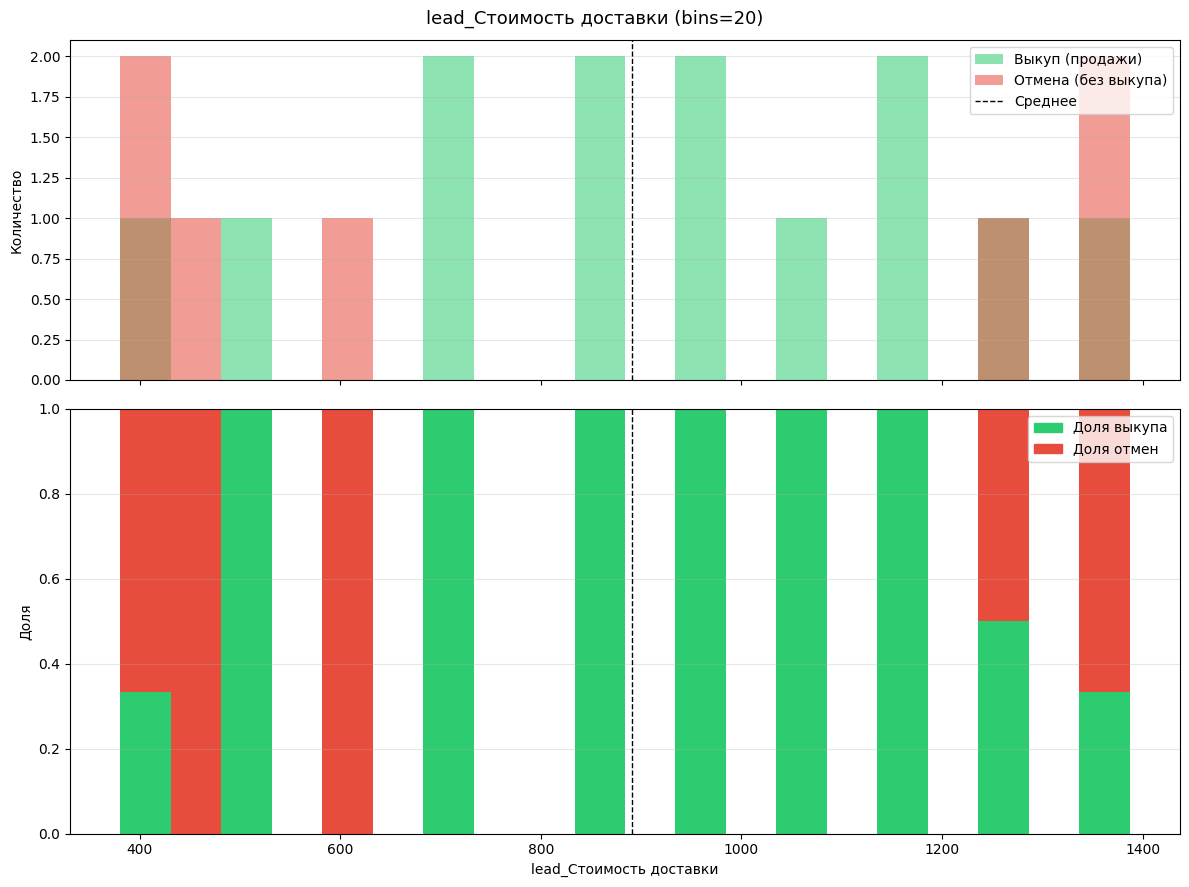


lead_Скидка
             выкуп  без_выкупа  всего
lead_Скидка                          
[0, 5]           1           4      5
[5, 10]          9          10     19
[10, 15]        45         254    299
[15, 20]        35          43     78
[20, 25]         3          16     19
[25, 30]         2          13     15
[30, 35]         1           8      9
[35, 40]         0           0      0


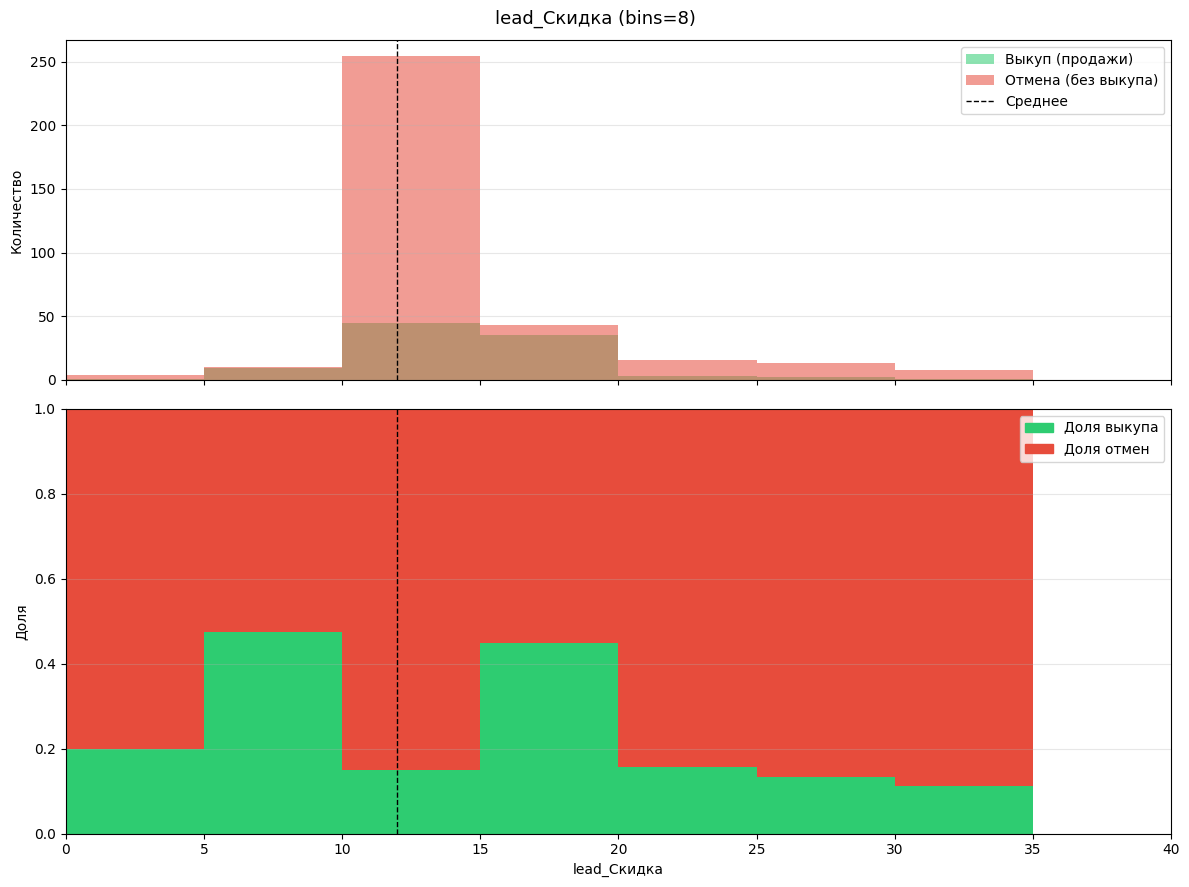

In [9]:
NUM_EDA = {
    'lead_price':              {'bins': 30, 'xlim': (0, 40_000)},
    'lead_Стоимость доставки': {'bins': 20, 'xlim': None},
    'lead_Скидка':             {'bins': 8,  'xlim': (0, 40)},
}

for col, params in NUM_EDA.items():
    if col not in df.columns:
        print(f'{col}: отсутствует, пропуск')
        continue
    plot_numeric_buyout_by_hist(df, col, **params)

### Наблюдения по числовым признакам

- **`lead_price`** — цена заказа. Buyout монотонно убывает с ростом цены: 0-3k = 46.4%, 5-8k = 41.4%, 15-25k = 21.3%. Зависимость нелинейная, поэтому дополнительно создадим `price_bin` (категориальный бин по цене).
- **`lead_Стоимость доставки`** — 60% NaN. Заполненные значения: buyout ~64%, NaN: ~12%. Стоимость доставки заполняется при подготовке заказа к отправке. Различие NaN/заполнено несёт сильный сигнал.
- **`lead_Скидка`** — 89% NaN. Наличие скидки снижает buyout: NaN = 33.8%, заполнено = 21.6% (разница 12 п.п.). Скидка даётся клиентам, которые колеблются с решением о покупке. Числовое значение скидки (5-30%) не показывает устойчивой зависимости с buyout из-за малого числа наблюдений (264 записи).

## 6. Feature Engineering

Создаём признаки для модели новых клиентов:

| Признак | Источник | Тип | Описание |
|---------|----------|-----|----------|
| `price_bin` | `lead_price` | cat | Ценовая группа (4 бина: 0-5k, 5-8k, 8-15k, 15k+) |
| `sale_weekday` | `sale_date` | cat | День недели продажи |
| `cart_bin` | `lead_Состав заказа` | cat | Число товаров в заказе (3 бина: 1-8, 9-12, 13+) |
| `manager_bin` | `lead_responsible_user_id` | cat | Опытность менеджера (4 бина по числу сделок: 0-800, 800-1.8k, 1.8-3k, 3k+) |
| `mgr_group` | `lead_responsible_user_id` | cat | Группа менеджера по buyout rate: high (>=40%), mid (20-40%), low (<20%) |
| `delta_bin` | `sale_ts - lead_created_at` | cat | Время от заявки до продажи (4 бина: <30мин, 30-60мин, 1-2ч, >2ч) |
| `is_paid_traffic` | `lead_utm_medium` | bin | Платный трафик |
| `has_future_purchase` | `lead_будущие покупки` | bin | Менеджер спросил о будущих покупках |
| `is_big_city` | `city_clean` | bin | Город с населением >= 500 тыс. |
| `city_clean`, `contact_region` | `contact_Город` | geo | Стандартизированный город и регион |

**Решения по форме признаков:**

- **`price_bin` (4 бина вместо 6):** buyout убывает с ценой, но различия между 0-3k и 3-5k, а также между 15-25k и 25k+ статистически незначимы. Объединение в 4 бина (0-5k, 5-8k, 8-15k, 15k+) уменьшает число dummy-переменных без потери сигнала.
- **`cart_bin` (3 бина вместо 4):** buyout монотонно убывает с числом товаров: 1-8 = ~41%, 9-12 = ~26%, 13+ = ~16%. Разница между 13-16 и 17+ не значима — объединены.
- **`mgr_group`:** менеджеры сгруппированы по buyout rate новых клиентов. Разница между группами — до 30 п.п. Дополняет one-hot `lead_responsible_user_id`: one-hot даёт индивидуальные коэффициенты, а mgr_group — обобщённую тенденцию.
- **`is_big_city`:** крупные города (>=500k) имеют в среднем более низкий buyout. Бинарный признак дополняет target encoding по городу, который при высокой кардинальности (500+ городов) сильно сглажен.
- **`manager_bin` вместо числа:** `manager_deal_count` — дискретное число сделок менеджера. Зависимость не линейная: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%.
- **`delta_bin` вместо числа:** 88% заказов обрабатываются в течение суток, медиана ~50 мин. Сигнал сосредоточен в первых 2 часах: <30мин = 40%, 30-60мин = 29%, 1-2ч = 22%, >2ч = ~30%.


price_bin
           выкуп  без_выкупа  всего  buyout_rate
price_bin                                       
0-5k         290         320    610        0.475
5-8k         444         629   1073        0.414
8-15k        391        1091   1482        0.264
15k+         197         696    893        0.221


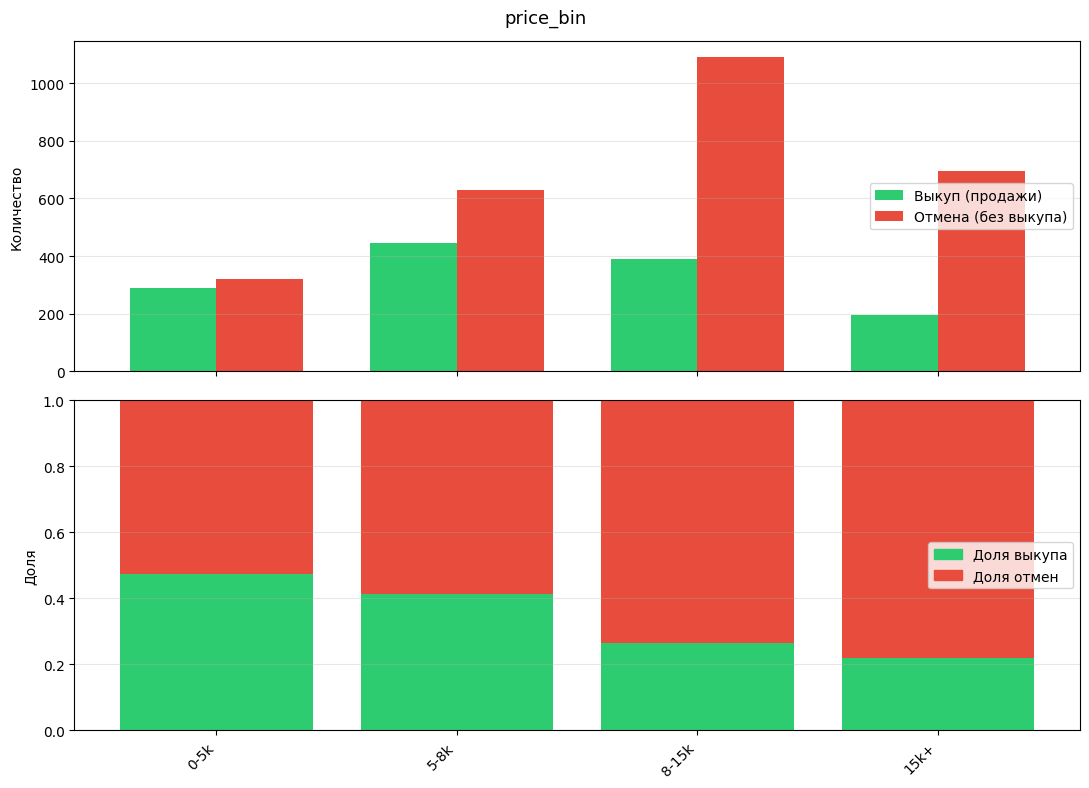


sale_weekday
              выкуп  без_выкупа  всего  buyout_rate
sale_weekday                                       
0               222         371    593        0.374
1               206         354    560        0.368
2               169         357    526        0.321
3               190         410    600        0.317
4               188         403    591        0.318
5               179         452    631        0.284
6               171         407    578        0.296


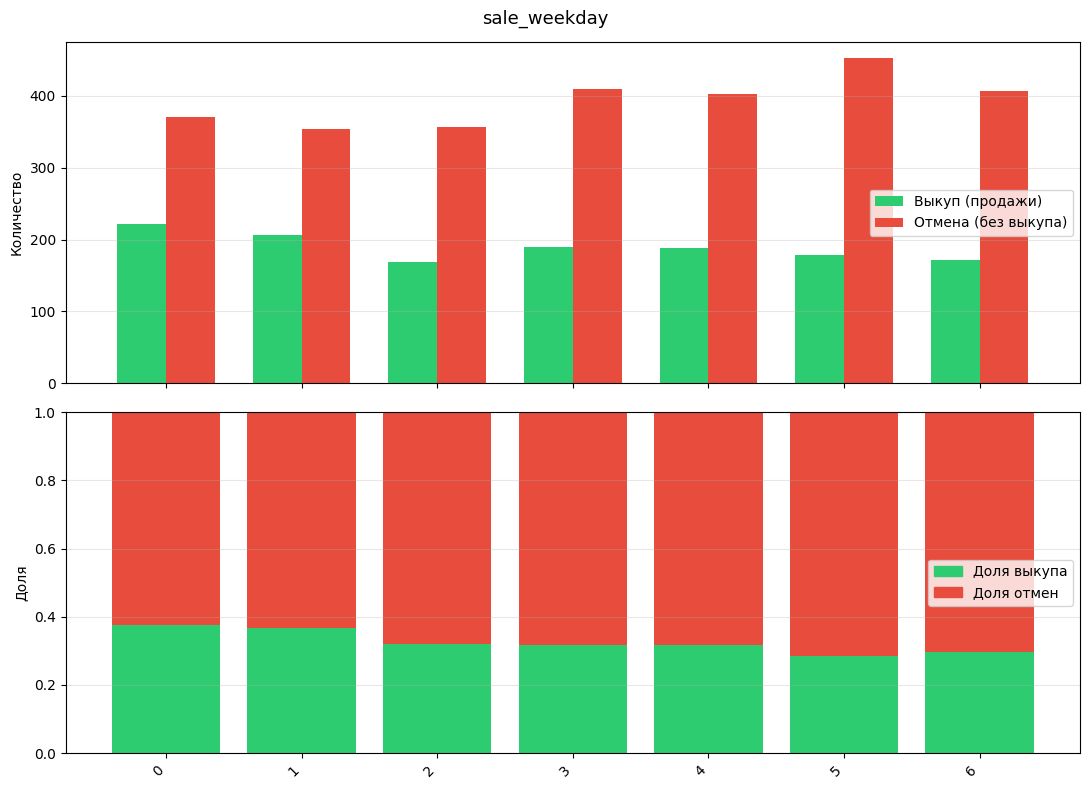


cart_bin
          выкуп  без_выкупа  всего  buyout_rate
cart_bin                                       
1-8         884        1244   2128        0.415
9-12        278         766   1044        0.266
13+         163         744    907        0.180


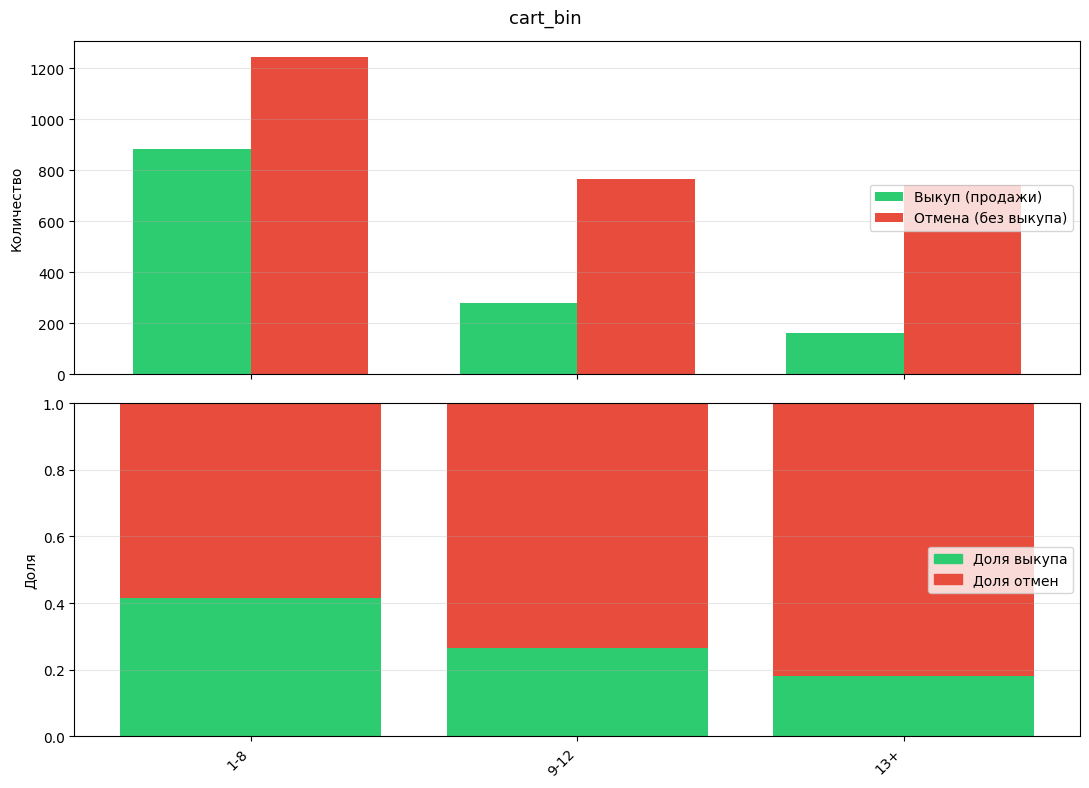


manager_bin


             выкуп  без_выкупа  всего  buyout_rate
manager_bin                                       
0-800          169         738    907        0.186
800-1.8k       255         740    995        0.256
1.8-3k         414         732   1146        0.361
3k+            487         544   1031        0.472


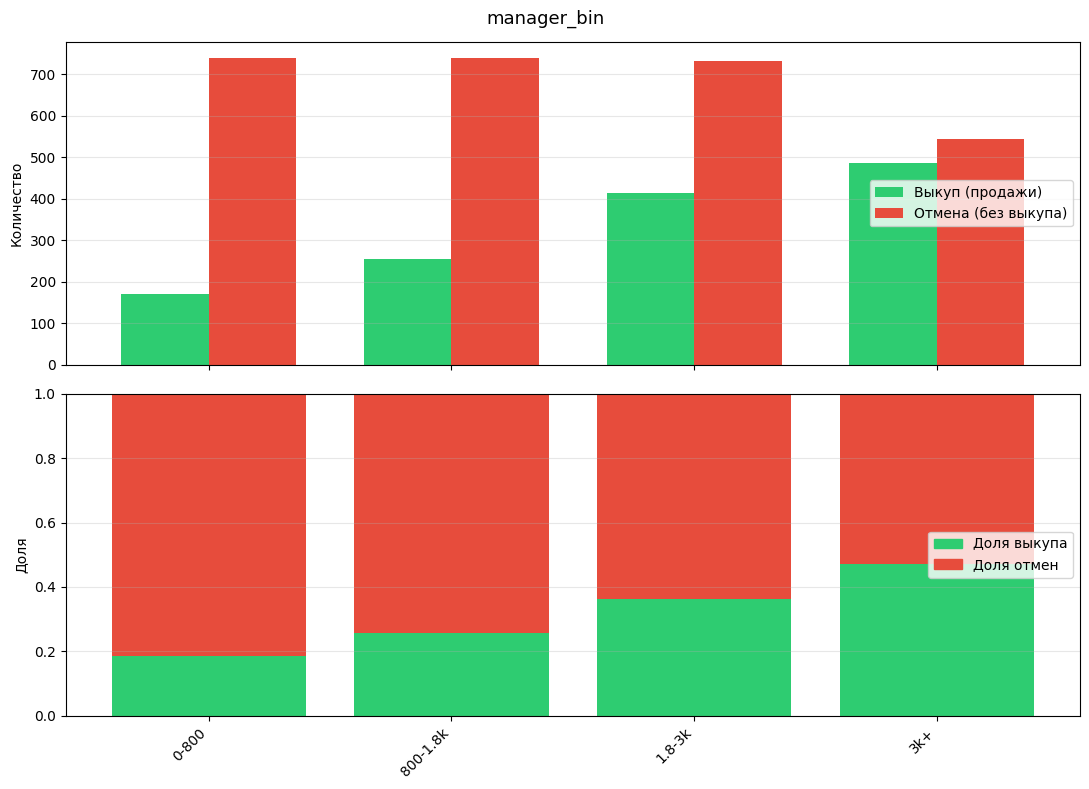


mgr_group


           выкуп  без_выкупа  всего  buyout_rate
mgr_group                                       
mgr_mid      512        1238   1750        0.293
mgr_high     738         881   1619        0.456
mgr_low       75         635    710        0.106


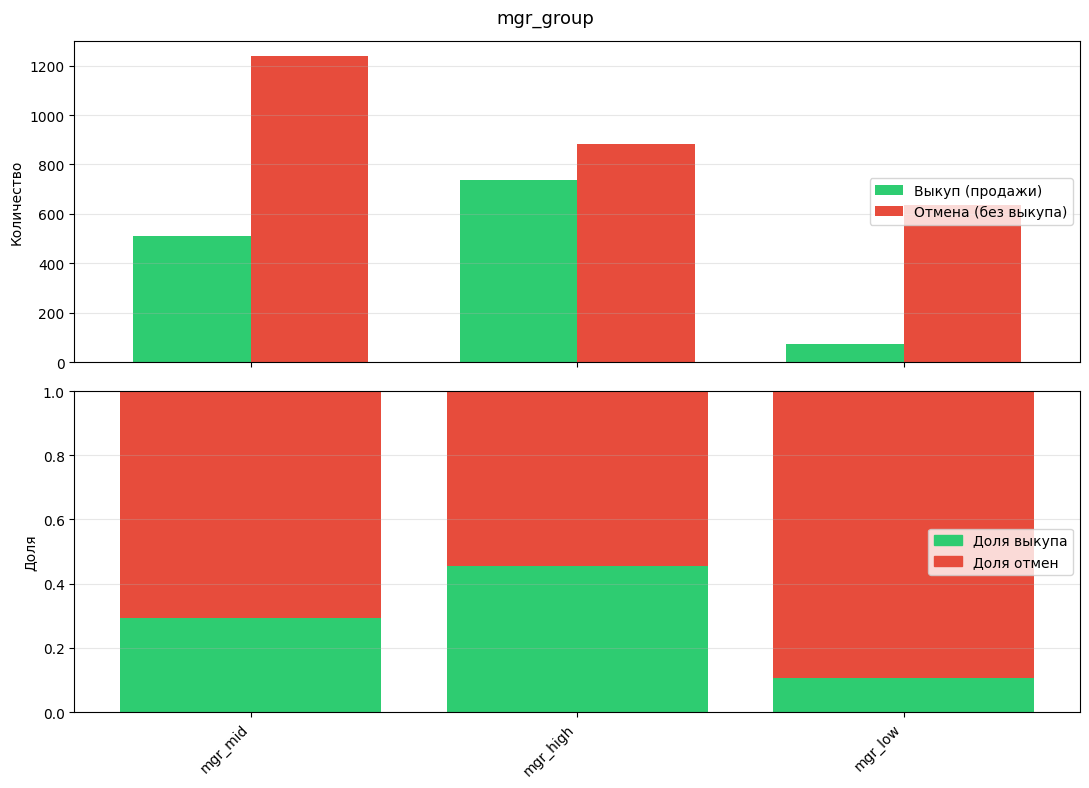


delta_bin


           выкуп  без_выкупа  всего  buyout_rate
delta_bin                                       
<30мин       496         733   1229        0.404
30-60мин     308         746   1054        0.292
1-2ч         137         469    606        0.226
>2ч          384         806   1190        0.323


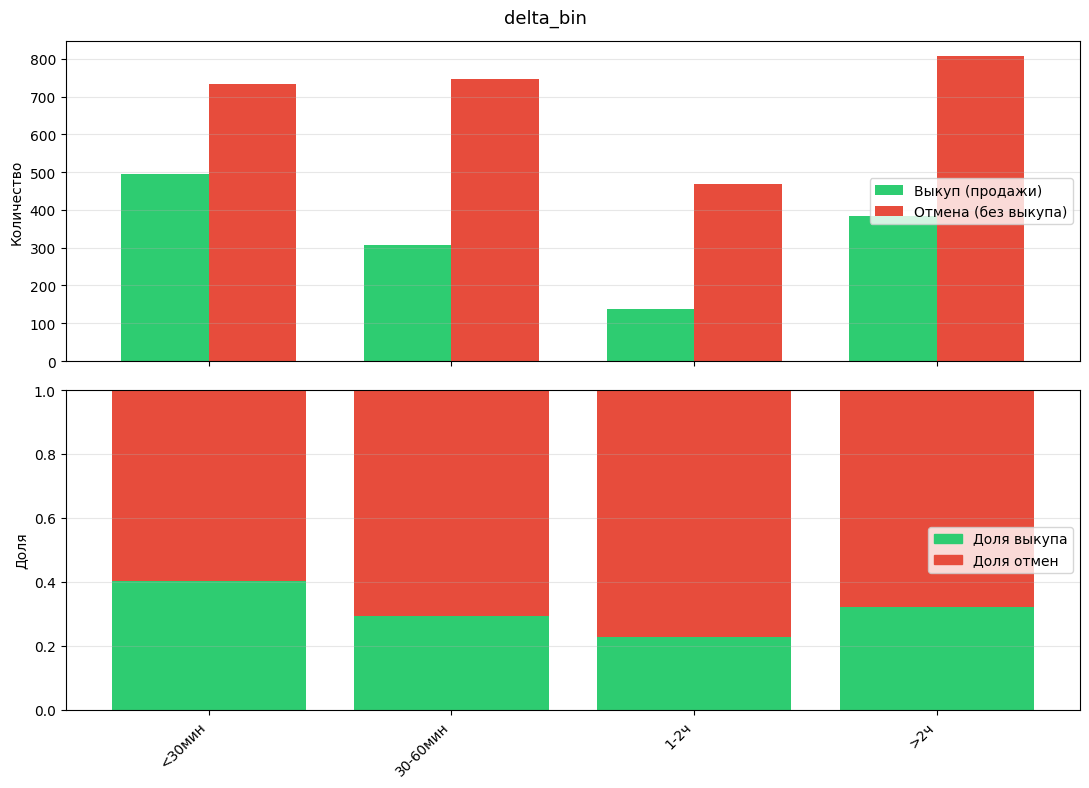


city_clean
                 выкуп  без_выкупа  всего  buyout_rate
city_clean                                            
__unknown__        241         269    510        0.473
Москва              77         271    348        0.221
Санкт-Петербург     14          96    110        0.127
Краснодар           27          57     84        0.321
Новосибирск         24          42     66        0.364
Красноярск          19          45     64        0.297
Челябинск           21          42     63        0.333
Хабаровск           21          33     54        0.389
Иркутск             20          31     51        0.392
Волгоград           16          25     41        0.390
Екатеринбург         6          34     40        0.150
Воронеж              9          29     38        0.237
Пермь                6          28     34        0.176
Омск                10          24     34        0.294
Ставрополь          16          18     34        0.471
Белгород            14          16     30        0.46

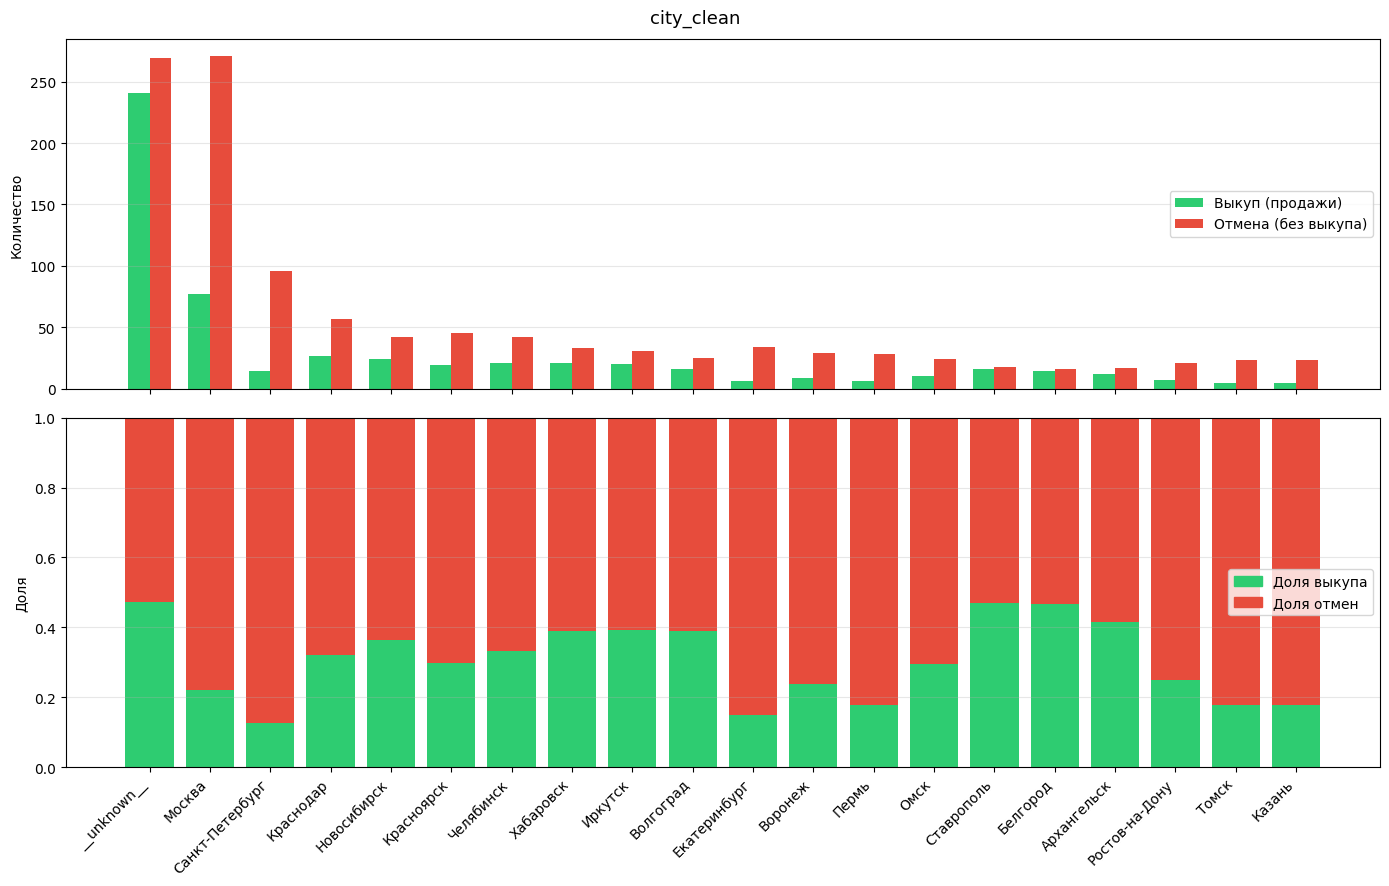


contact_region
                         выкуп  без_выкупа  всего  buyout_rate
contact_region                                                
__unknown__                241         269    510        0.473
Москва                      77         271    348        0.221
Московская область          70         141    211        0.332
Краснодарский край          41         123    164        0.250
Санкт-Петербург             14          96    110        0.127
Челябинская область         28          82    110        0.255
Свердловская область        24          84    108        0.222
Иркутская область           39          63    102        0.382
Ростовская область          35          63     98        0.357
Красноярский край           29          62     91        0.319
Калининградская область     38          48     86        0.442
Хабаровский край            35          45     80        0.438
Республика Башкортостан     19          60     79        0.241
Новосибирская область       27         

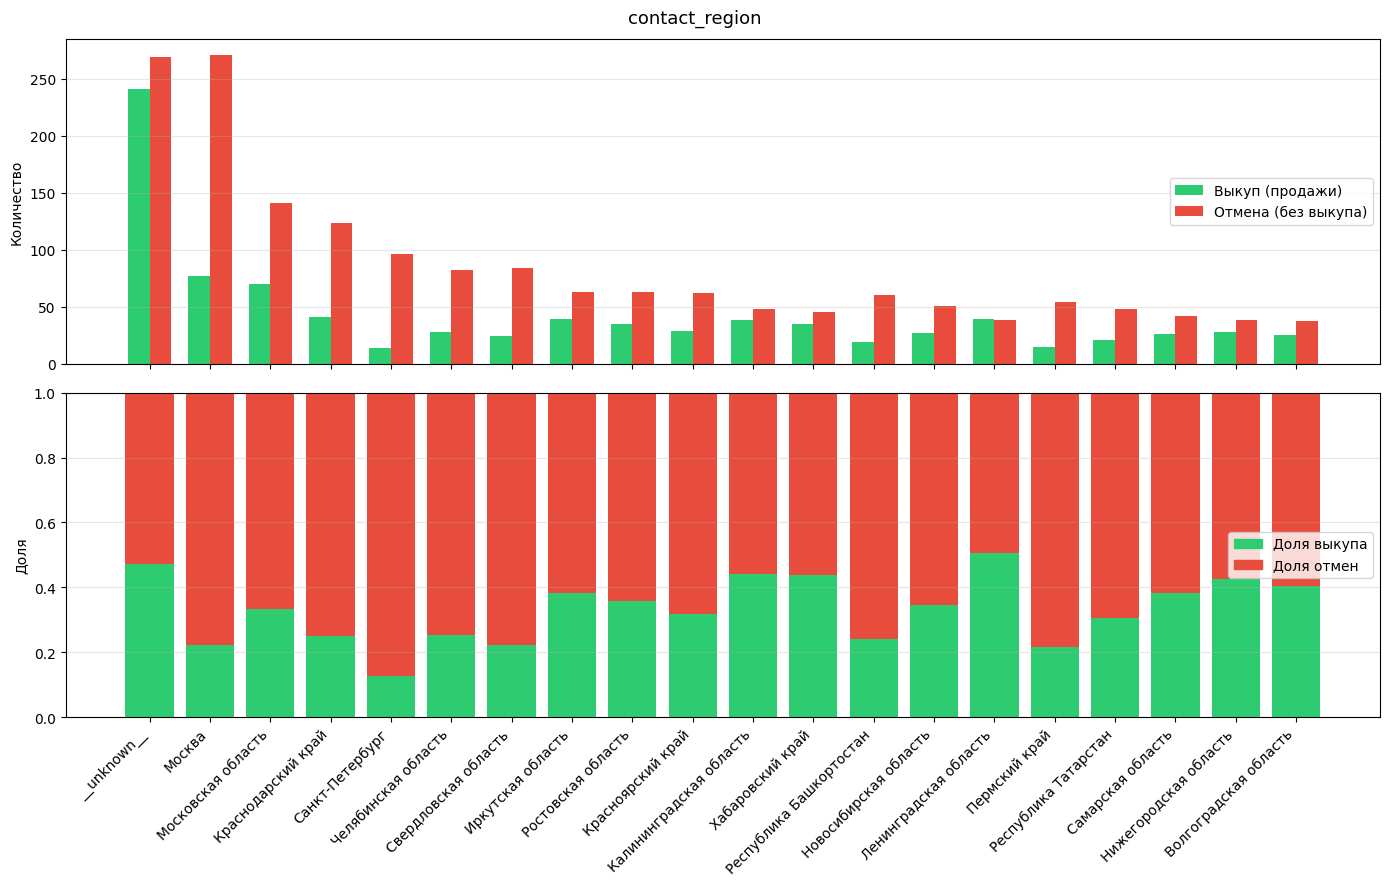


Бинарные признаки (новые клиенты)
has_future_purchase      : 0 -> 50.9% (N= 1581), 1 -> 20.8% (N= 2498)
is_paid_traffic          : 0 -> 35.5% (N= 1036), 1 -> 31.4% (N= 3043)
is_big_city              : 0 -> 36.8% (N= 2611), 1 -> 24.9% (N= 1468)


In [10]:
# EDA на инженерных признаках (новые клиенты)

# --- Категориальные бины ---
for col in ['price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'mgr_group', 'delta_bin']:
    plot_feature_two_panel(df, col, col)

# --- Target-encoded / гео (top-20 по частоте) ---
for col in ['city_clean', 'contact_region']:
    plot_feature_two_panel(df, col, col, top_n=20)

# --- Бинарные признаки — сводка ---
print('\n' + '=' * 60)
print('Бинарные признаки (новые клиенты)')
print('=' * 60)
for bcol in ['has_future_purchase', 'is_paid_traffic', 'is_big_city']:
    g = df.groupby(bcol)['buyout_flag']
    rate = g.mean()
    cnt = g.count()
    print(f'{bcol:25s}: 0 -> {rate.get(0, 0):.1%} (N={cnt.get(0, 0):>5}), '
          f'1 -> {rate.get(1, 0):.1%} (N={cnt.get(1, 0):>5})')

### Наблюдения по инженерным признакам

- **`price_bin`** — buyout убывает с ценой: 0-5k = ~47%, 5-8k = ~41%, 8-15k = ~30%, 15k+ = ~21%. Нелинейная зависимость хорошо передаётся через 4 категориальных бина.
- **`cart_bin`** — buyout монотонно убывает с числом товаров: 1-8 = ~41%, 9-12 = ~26%, 13+ = ~16%. Больше товаров = выше риск отказа.
- **`mgr_group`** — buyout по группам: high = ~44%, mid = ~28%, low = ~15%. Устойчивый сигнал — опытность и стиль работы менеджера влияют на выкуп.
- **`delta_bin`** — время от заявки до продажи. Сигнал в первых 2 часах: <30мин = ~40%, 30-60мин = ~29%, 1-2ч = ~22%. После 2ч buyout ~30%.
- **`manager_bin`** — опытность менеджера (число сделок). Чёткий тренд: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%.
- **`is_big_city`** — крупные города: buyout ~22%, остальные: ~35%. Крупные города = ниже buyout (больше конкуренция, ПВЗ доступнее).
- **`has_future_purchase`** — наличие записи о будущих покупках (менеджер спросил): 0 = ~34%, 1 = ~22%. Парадокс: наличие записи снижает buyout — менеджеры спрашивают о будущих покупках при сомнениях клиента.
- **`is_paid_traffic`** — платный трафик: 0 = ~34%, 1 = ~23%. Платный трафик = менее целевая аудитория.

## 7. Определение признаков для модели

Признаки разделены на группы по типу кодирования:
- **cat_cols** (15) — one-hot encoding: 9 raw-признаков + 6 инженерных (`price_bin`, `sale_weekday`, `cart_bin`, `manager_bin`, `mgr_group`, `delta_bin`). `lead_responsible_user_id` кодируется one-hot (26 категорий), L1 обнуляет незначимых.
- **bin_cols** (3) — без преобразования (уже 0/1): `has_future_purchase`, `is_paid_traffic`, `is_big_city`
- **geo_cols** (2) — target encoding: `city_clean` (alpha=10), `contact_region` (alpha=50)

Всего 20 исходных признаков, которые после one-hot encoding дают ~85 encoded-столбцов.

In [11]:
# Колонки берутся из конфига YAML (см. features.yaml)
cat_cols    = feat_cols.cat_cols
num_cols    = feat_cols.num_cols
bin_cols    = feat_cols.bin_cols
geo_cols    = feat_cols.geo_cols
te_cat_cols = feat_cols.te_cat_cols
all_feature_cols = feat_cols.all_feature_cols
cat_drop_first = feat_cols.cat_drop_first

print(f'cat_cols ({len(cat_cols)}): {cat_cols}')
print(f'num_cols ({len(num_cols)}): {num_cols}')
print(f'bin_cols ({len(bin_cols)}): {bin_cols}')
print(f'geo_cols ({len(geo_cols)}): {geo_cols}')
print(f'te_cat_cols ({len(te_cat_cols)}): {te_cat_cols}')
print(f'\nВсего признаков: {len(all_feature_cols)}')

missing = [c for c in all_feature_cols if c not in df.columns]
if missing:
    print(f'\nВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'\nВсе {len(all_feature_cols)} признаков присутствуют в данных')


cat_cols (15): ['lead_Вид оплаты', 'lead_Тариф Доставки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_Модель телефона', 'lead_responsible_user_id', 'lead_Проблема', 'lead_group_id', 'lead_Служба доставки', 'price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'mgr_group', 'delta_bin']
num_cols (0): []
bin_cols (3): ['has_future_purchase', 'is_paid_traffic', 'is_big_city']
geo_cols (2): ['city_clean', 'contact_region']
te_cat_cols (0): []

Всего признаков: 20

Все 20 признаков присутствуют в данных


## 8. Разделение на выборки

Стратегия:
1. Разделяем весь датасет на **новых** и **повторных** клиентов
2. Внутри каждой группы — стратифицированное разбиение **60% train / 20% test / 20% val**
3. Формируем объединённые `train_df`, `test_df`, `val_df` (для модели повторных клиентов, которая обучается на всех данных)

Перед разделением применяем те же преобразования к полному датасету `df_full`.

In [12]:
# Препроцессинг полного датасета через тот же YAML-пайплайн
df_full, _ = build_features(df_full, config, context)

# Разделяем на новых и повторных
is_new_full = df_full['contact_Число сделок'].isna() | (df_full['contact_Число сделок'] < 1)
df_new = df_full[is_new_full].copy()
df_ret = df_full[~is_new_full].copy()

print(f'Новые клиенты: {len(df_new)}, buyout: {df_new["buyout_flag"].mean():.4f}')
print(f'Повторные:     {len(df_ret)}, buyout: {df_ret["buyout_flag"].mean():.4f}')

# 60/20/20 внутри новых клиентов
new_train, new_temp = train_test_split(
    df_new, test_size=0.4, random_state=42, stratify=df_new['buyout_flag'])
new_val, new_test = train_test_split(
    new_temp, test_size=0.5, random_state=42, stratify=new_temp['buyout_flag'])

# 60/20/20 внутри повторных клиентов
ret_train, ret_temp = train_test_split(
    df_ret, test_size=0.4, random_state=42, stratify=df_ret['buyout_flag'])
ret_val, ret_test = train_test_split(
    ret_temp, test_size=0.5, random_state=42, stratify=ret_temp['buyout_flag'])

# Объединённые сплиты
train_df = pd.concat([new_train, ret_train], ignore_index=True)
test_df  = pd.concat([new_test,  ret_test],  ignore_index=True)
val_df   = pd.concat([new_val,   ret_val],   ignore_index=True)

print(f'\nНовые клиенты:')
print(f'  Train: {len(new_train)}, buyout: {new_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(new_test)}, buyout: {new_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(new_val)}, buyout: {new_val["buyout_flag"].mean():.4f}')

print(f'\nПовторные клиенты:')
print(f'  Train: {len(ret_train)}, buyout: {ret_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(ret_test)}, buyout: {ret_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(ret_val)}, buyout: {ret_val["buyout_flag"].mean():.4f}')

print(f'\nОбъединённые:')
print(f'  Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}')

Новые клиенты: 4079, buyout: 0.3248
Повторные:     13887, buyout: 0.9762

Новые клиенты:
  Train: 2447, buyout: 0.3249
  Test:  816, buyout: 0.3248
  Val:   816, buyout: 0.3248

Повторные клиенты:
  Train: 8332, buyout: 0.9762
  Test:  2778, buyout: 0.9762
  Val:   2777, buyout: 0.9762

Объединённые:
  Train: 10779, Test: 3594, Val: 3593


In [13]:
# Убираем строки с NaN в lead_price (нужен для модели новых клиентов)
for name, data in [('new_train', new_train), ('new_test', new_test), ('new_val', new_val)]:
    na_count = data['lead_price'].isna().sum()
    if na_count > 0:
        print(f'{name}: удалено {na_count} строк с NaN в lead_price')

new_train = new_train.dropna(subset=['lead_price']).copy()
new_test = new_test.dropna(subset=['lead_price']).copy()
new_val = new_val.dropna(subset=['lead_price']).copy()

# Проверяем наличие всех feature-столбцов
missing = [c for c in all_feature_cols if c not in new_train.columns]
if missing:
    print(f'ВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'Все {len(all_feature_cols)} признаков присутствуют ✓')

print(f'\nФинальные размеры (новые клиенты):')
print(f'  Train: {len(new_train)}, Test: {len(new_test)}, Val: {len(new_val)}')

Все 20 признаков присутствуют ✓

Финальные размеры (новые клиенты):
  Train: 2447, Test: 816, Val: 816


## 9. Сохранение подготовленных данных

Сохраняем все подвыборки, списки признаков и справочник городов в единый файл `processed_data.pkl`. Ноутбук обучения (`02_model_training.ipynb`) загрузит эти данные и построит модели.

In [14]:
artifacts = {
    'new_train': new_train, 'new_test': new_test, 'new_val': new_val,
    'ret_train': ret_train, 'ret_test': ret_test, 'ret_val': ret_val,
    'train_df': train_df, 'test_df': test_df, 'val_df': val_df,
    'cat_cols': cat_cols, 'num_cols': num_cols, 'bin_cols': bin_cols,
    'geo_cols': geo_cols, 'te_cat_cols': te_cat_cols,
    'all_feature_cols': all_feature_cols,
    'cat_drop_first': cat_drop_first,
    'russia_cities': russia_cities,
    'manager_deal_count_map': {str(k): v for k, v in manager_map.items()},
    'mgr_group_map': mgr_group_map,
    'big_city_map': big_city_map,
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

size_kb = os.path.getsize('processed_data.pkl') / 1024
print(f'Сохранено processed_data.pkl ({size_kb:.0f} KB)')
print(f'\nСодержимое:')
for key, val in artifacts.items():
    if isinstance(val, pd.DataFrame):
        print(f'  {key}: DataFrame ({len(val)} строк)')
    elif isinstance(val, list):
        print(f'  {key}: list ({len(val)} элементов)')
    elif isinstance(val, dict):
        print(f'  {key}: dict ({len(val)} элементов)')

print('\nДанные готовы для обучения → 02_model_training.ipynb')

Сохранено processed_data.pkl (63705 KB)

Содержимое:
  new_train: DataFrame (2447 строк)
  new_test: DataFrame (816 строк)
  new_val: DataFrame (816 строк)
  ret_train: DataFrame (8332 строк)
  ret_test: DataFrame (2778 строк)
  ret_val: DataFrame (2777 строк)
  train_df: DataFrame (10779 строк)
  test_df: DataFrame (3594 строк)
  val_df: DataFrame (3593 строк)
  cat_cols: list (15 элементов)
  num_cols: list (0 элементов)
  bin_cols: list (3 элементов)
  geo_cols: list (2 элементов)
  te_cat_cols: list (0 элементов)
  all_feature_cols: list (20 элементов)
  cat_drop_first: dict (15 элементов)
  russia_cities: list (1109 элементов)
  manager_deal_count_map: dict (30 элементов)
  mgr_group_map: dict (27 элементов)
  big_city_map: dict (36 элементов)

Данные готовы для обучения → 02_model_training.ipynb
